In [1]:
import numpy as np
import pandas as pd
import os
import glob
import itertools
import scanpy as sc
import natsort
import json

import matplotlib.pyplot as plt
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

In [2]:
class Bigtensor_lite():
    def __init__(self, f_data, f_meta):
        
        bigtensor = np.load(f_data)
        with open(f_meta, 'r') as fp:
            meta = json.load(fp)

        dim = len(meta['size'])
        
        if dim == 3:
            self.nf, self.nc, self.ng = meta['size']
            self.conds = np.array(meta['dim0'])
            self.types = np.array(meta['dim1'])
            self.genes = np.array(meta['dim2'])
            
        elif dim == 4:
            self.nf, _, self.nc, self.ng = meta['size']
            self.conds = np.array(meta['dim0'])
            self.types = np.array(meta['dim2'])
            self.genes = np.array(meta['dim3'])
            
            bigtensor = np.nanmean(bigtensor, axis=1)
            
        self.bt = bigtensor

        # self.conds_time = np.array([int(cond[1:-2]) for cond in self.conds])
        # self.conds_anno = np.array([cond[-2:] for cond in self.conds])
        # self.conds_color = pd.Series(self.palette).loc[self.conds_anno].values 
        
        return
    
    def get_conds_idx(self, query_conds): 
        """
        """
        conds_idx = basicu.get_index_from_array(self.conds, query_conds)
        assert np.any(conds_idx != -1)
        return conds_idx
            
    def get_types_idx(self, query_types):
        """
        """
        types_idx = basicu.get_index_from_array(self.types, query_types)
        assert np.any(types_idx != -1)
        return types_idx
            
    def get_genes_idx(self, query_genes):
        """
        """
        genes_idx = basicu.get_index_from_array(self.genes, query_genes)
        assert np.any(genes_idx != -1)
        return genes_idx
            
    
    def plot_one_lite(self, ax, selected_type, selected_gene, annotate=True, color='k'):
        """
        """
        type_idx = basicu.get_index_from_array(self.types, [selected_type])[0]
        gene_idx = basicu.get_index_from_array(self.genes, [selected_gene])[0]
        assert gene_idx != -1

        vals = self.bigtensor[:,:,type_idx, gene_idx] # cond by rep
        vals_mean = np.nanmean(vals, axis=1)


        ax.set_title(f'{selected_gene} in {selected_type}')
        

In [3]:
ddir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/res'

In [4]:
f_data = os.path.join(ddir, 'bigtensor_subclass_it_15bin.npy')
f_meta = os.path.join(ddir, 'bigtensor_subclass_it_15bin.json')

bt = Bigtensor_lite(f_data, f_meta)
bt_name = 'Yoo25'
bt_color = 'black'

In [5]:
bt.bt.shape

(11, 15, 16567)

# Fosb in dev

In [6]:
qry_conds = [cond for cond in bt.conds if not cond.endswith('DR')]
print(qry_conds)

qry_times = np.array([cond[1:] for cond in qry_conds]).astype(int)
print(qry_times)

['P6', 'P8', 'P10', 'P12', 'P14', 'P17', 'P21']
[ 6  8 10 12 14 17 21]


# profile regulons

In [7]:
palette = sns.color_palette(palette='tab20c') #, n_colors=5)
palette

[(0.19215686274509805, 0.5098039215686274, 0.7411764705882353),
 (0.4196078431372549, 0.6823529411764706, 0.8392156862745098),
 (0.6196078431372549, 0.792156862745098, 0.8823529411764706),
 (0.7764705882352941, 0.8588235294117647, 0.9372549019607843),
 (0.9019607843137255, 0.3333333333333333, 0.050980392156862744),
 (0.9921568627450981, 0.5529411764705883, 0.23529411764705882),
 (0.9921568627450981, 0.6823529411764706, 0.4196078431372549),
 (0.9921568627450981, 0.8156862745098039, 0.6352941176470588),
 (0.19215686274509805, 0.6392156862745098, 0.32941176470588235),
 (0.4549019607843137, 0.7686274509803922, 0.4627450980392157),
 (0.6313725490196078, 0.8509803921568627, 0.6078431372549019),
 (0.7803921568627451, 0.9137254901960784, 0.7529411764705882),
 (0.4588235294117647, 0.4196078431372549, 0.6941176470588235),
 (0.6196078431372549, 0.6039215686274509, 0.7843137254901961),
 (0.7372549019607844, 0.7411764705882353, 0.8627450980392157),
 (0.8549019607843137, 0.8549019607843137, 0.9215686274509803),
 (0.38823529411764707, 0.38823529411764707, 0.38823529411764707),
 (0.5882352941176471, 0.5882352941176471, 0.5882352941176471),
 (0.7411764705882353, 0.7411764705882353, 0.7411764705882353),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627)]

In [8]:
type_colors1 = np.array(palette)[[0,2,6,4]]
type_colors2 = np.array(palette)[[4,7,10,8]]
type_colors3 = np.array(palette)[[8,14,12]]
# type_colors = np.array(palette)[[0,4,8]]

type_colors_list = [
    type_colors1,
    type_colors2,
    type_colors3,
]

In [9]:
np.where(qry_times==14)

(array([4]),)

In [10]:
ref_cond = 'P14'
ref_cond_idx = bt.get_conds_idx([ref_cond])[0]
ref_cond_idx

baseline_gexp = np.mean(bt.bt[ref_cond_idx], axis=0)#.shape
baseline_gexp

array([10.0771331 ,  4.2666755 ,  0.33982924, ...,  4.98870126,
        7.81381387,  3.88289447])

In [11]:
def plot2(reg_name, baseline_gexp, reg_genes=None, df_scenic=None):
    
    # ref_time = 14 
    
    if reg_genes is None:
        df_this_reg = df_scenic[df_scenic['Consensus_name']==reg_name]
        reg_genes   = df_this_reg['Gene'].unique()

    qry_gene_list = reg_genes
    qry_type_cols = [
        np.array(['0', '2', '4', '6']),
        np.array(['6', '8', '10', '12']),
        np.array(['12', '13', '14',]),
        ]
    
    fig, axs = plt.subplots(1,4,figsize=(3.5*4,5), sharex=True, sharey=True) 
    fig.suptitle(f'{reg_name} ({len(reg_genes)}g)', y=0.90, x=0.05, ha='left', fontsize=16)
    
    ax0 = axs[0]
    sns.despine(ax=ax0)
    ax0.grid(axis='x')
    
    axs = axs[1:]
    for i in range(3):
        ax = axs[i]
        qry_type_col = qry_type_cols[i]
        type_colors = type_colors_list[i]
        layer_name = ['sup', 'mid', 'deep'][i]
        
        sns.despine(ax=ax)
        ax.grid(axis='x')

        bt_this = bt

        cond_idx = bt_this.get_conds_idx(qry_conds)
        gene_idx_list = bt_this.get_genes_idx(qry_gene_list)
        assert np.all(gene_idx_list != -1)
        ax.set_title(layer_name)

        for j in range(len(qry_type_col)):

            qry_type = qry_type_col[j]
            type_idx = int(qry_type) #bt_this.get_types_idx([qry_type])[0]
            type_color = type_colors[j]

            val_mtx = bt_this.bt[cond_idx][:, type_idx, :][:,gene_idx_list]
            val_mtx -= baseline_gexp[gene_idx_list]
            val_vec = np.mean(val_mtx, axis=1)
            ax.plot(qry_times, val_vec, '-o', 
                    color=type_color, markerfacecolor='none', markersize=7,
                    label=qry_type.split(' ')[0],
                   )
            ax.legend(bbox_to_anchor=(1,1), loc='upper left', fontsize='x-small')
            
            ax0.plot(qry_times, val_vec, '-o', 
                    color=type_color, markerfacecolor='none', markersize=7,
                    label=qry_type.split(' ')[0],
                   )
            
    ax0.legend(bbox_to_anchor=(1,1), loc='upper left', fontsize='x-small')
    # ax0.legend(bbox_to_anchor=(0,-0.2), loc='upper left', ncol=2)

    # ax.set_xlim([-2,30])
    ax0.set_xticks([7,14,21])
    ax0.set_xlabel('Postnatal day (P)')
    ax0.set_ylabel('log2(FC)')
    fig.tight_layout()
    plt.show()

# Compare two different GRNs 

In [12]:
# scenic metadata
def get_scenic(f):
    df_scenic = pd.read_csv(f, index_col=0)
    df_scenic['signs'] = df_scenic['eRegulon_name'].apply(lambda x: x[-3]+x[-1])
    df_scenic['Consensus_name'] = df_scenic['TF']+df_scenic['signs']
    df_scenic = df_scenic[df_scenic['signs'].isin(["++", "-+"])]
    
    return df_scenic

f1 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/from_sanjana/L2_3_extended_e_regulon_metadata.csv'
f2 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/from_sanjana/L4_extended_e_regulon_metadata.csv'
f3 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/from_sanjana/L5IT_extended_e_regulon_metadata.csv'
f4 = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/from_sanjana/L6IT_extended_e_regulon_metadata.csv'

df_scenic1 = get_scenic(f1)
df_scenic2 = get_scenic(f2)
df_scenic3 = get_scenic(f3)
df_scenic4 = get_scenic(f4)

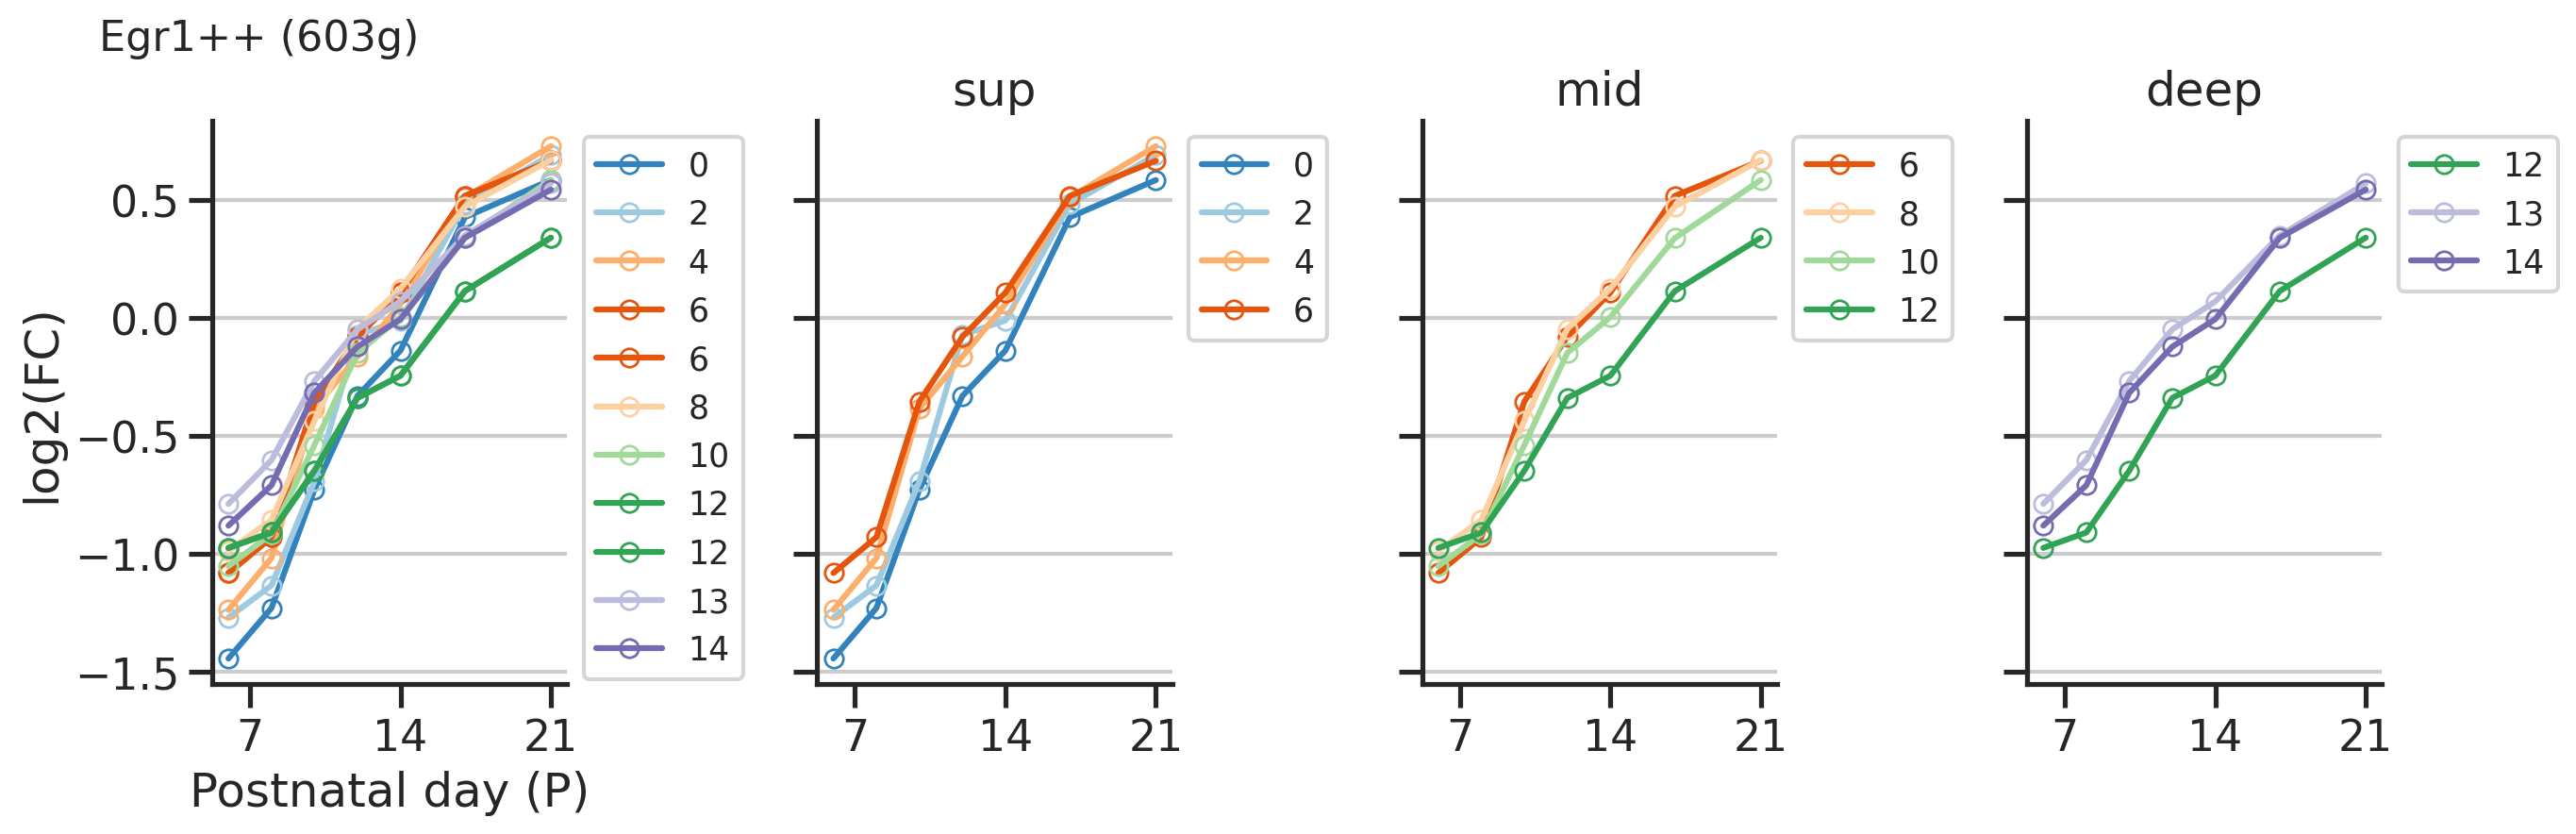

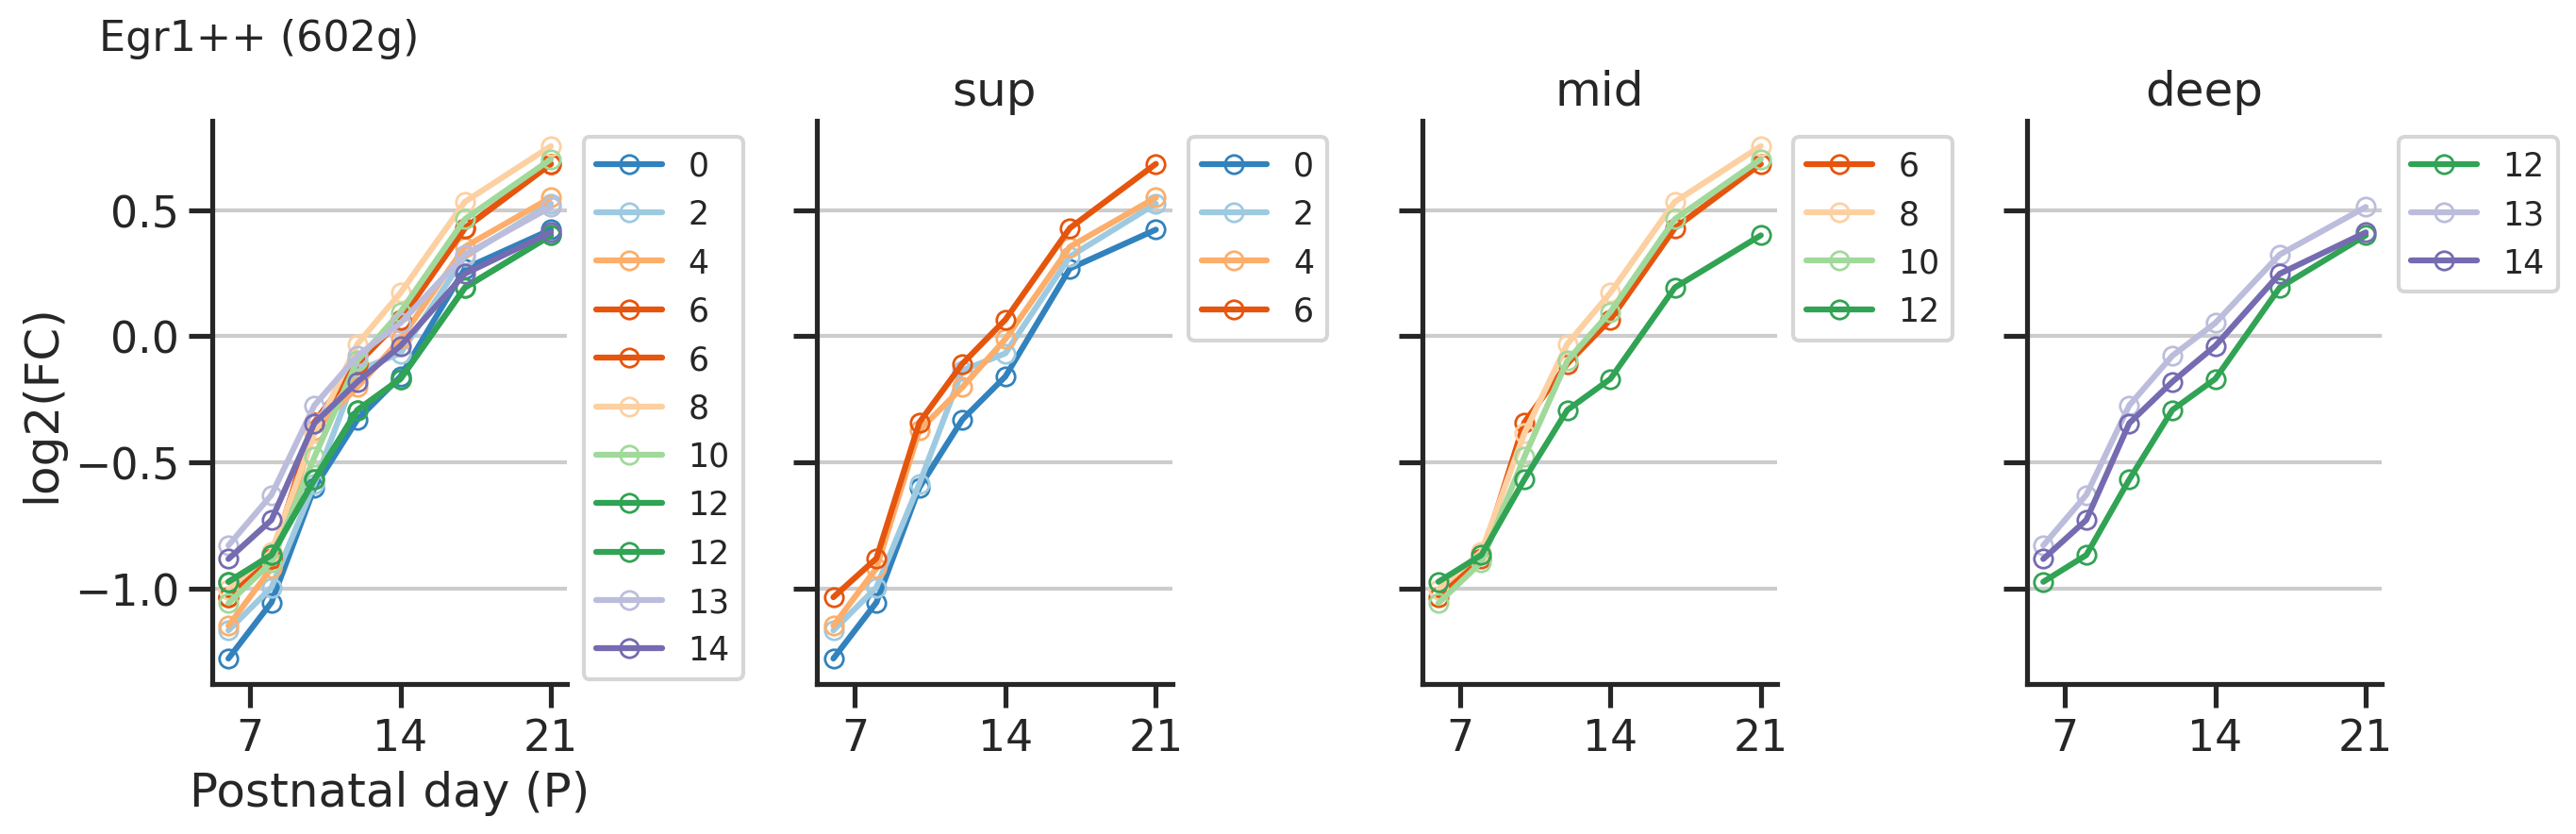

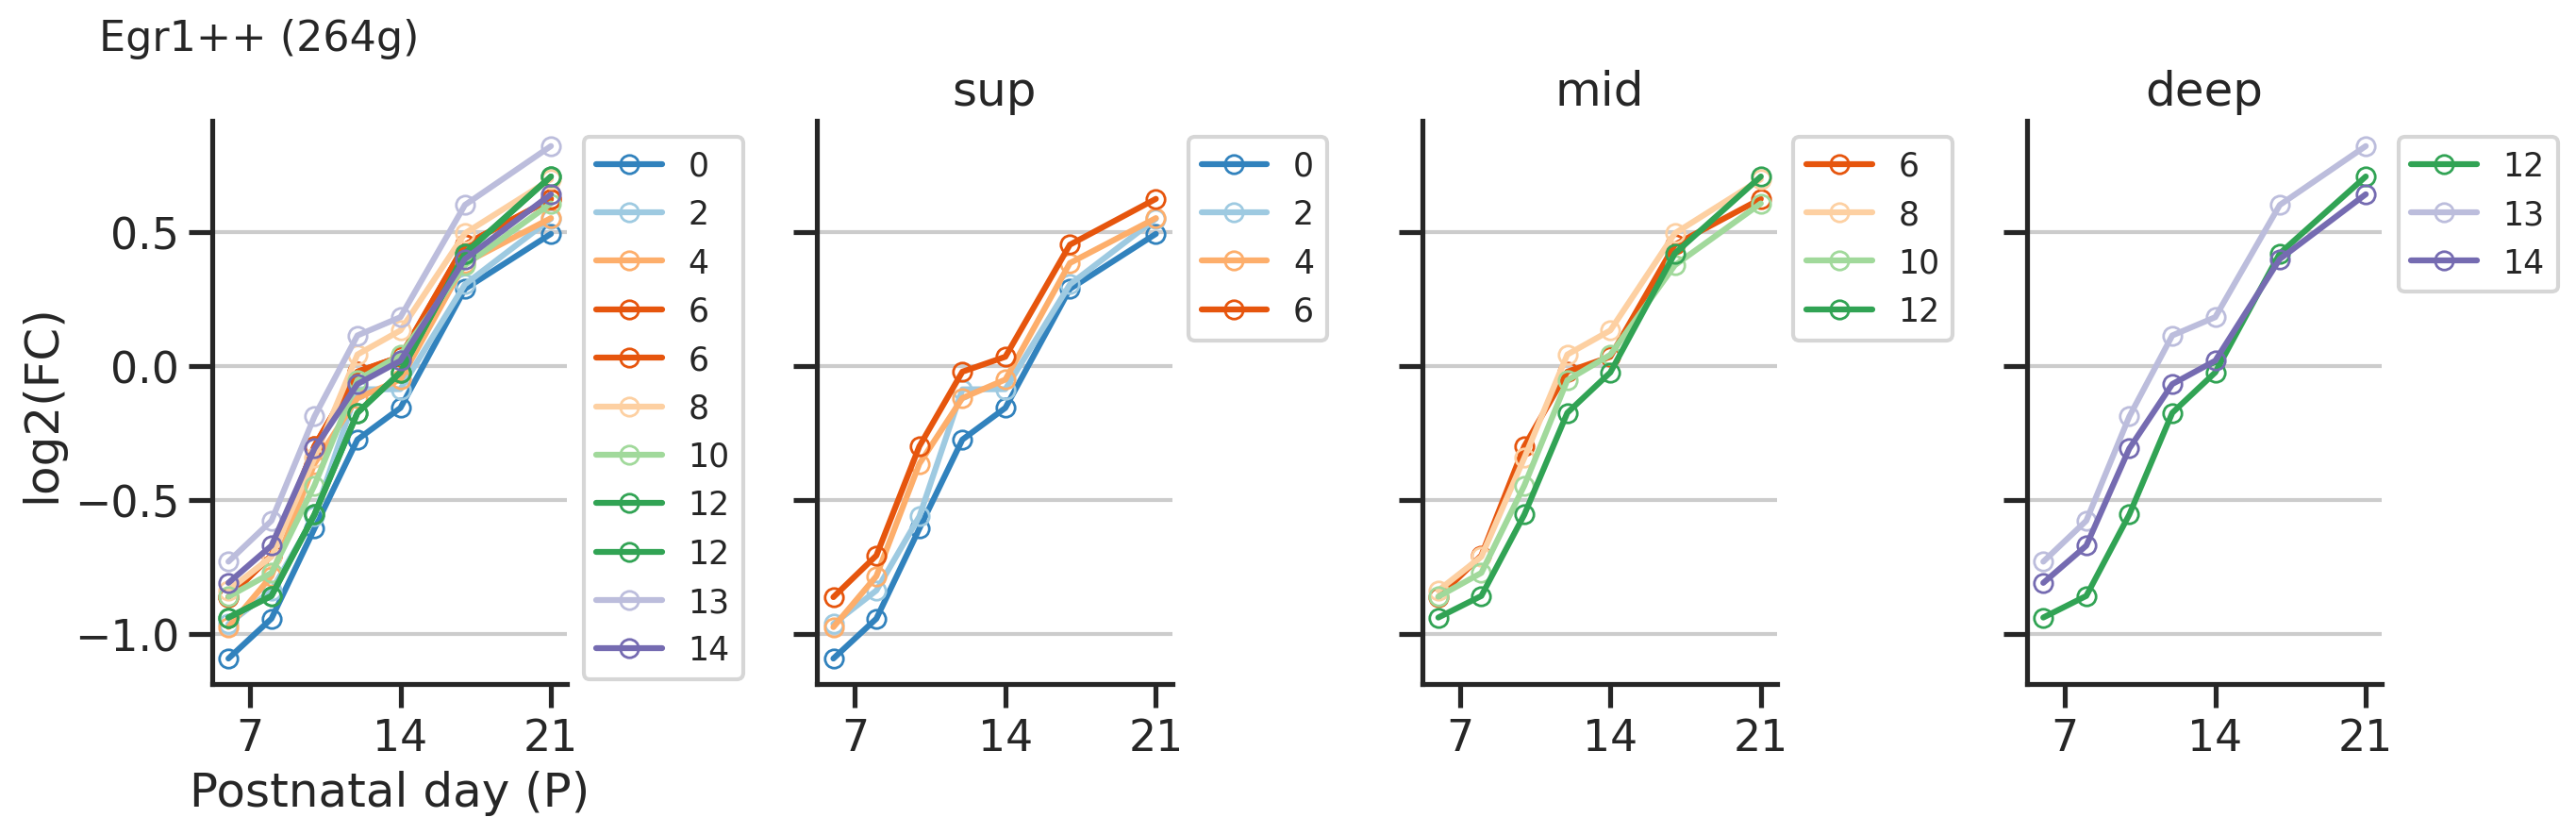

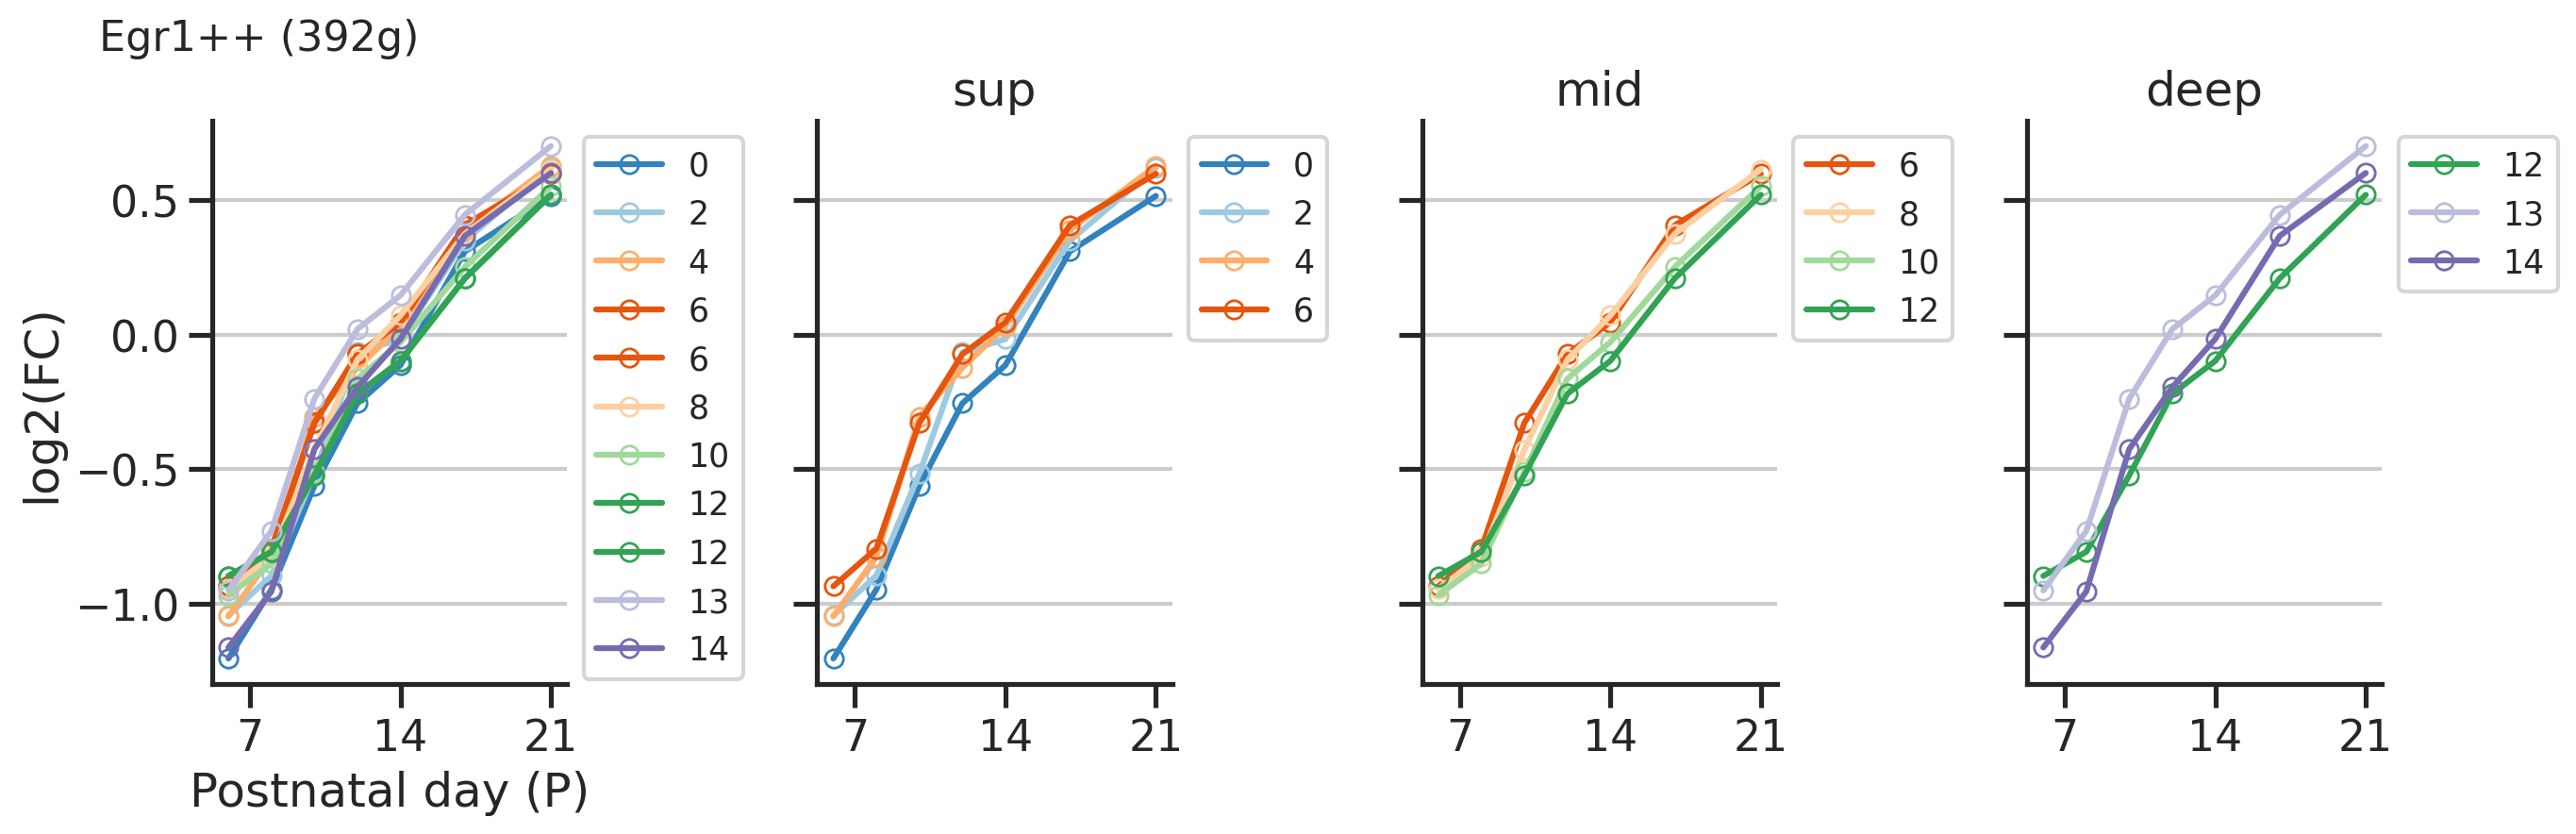

In [13]:
reg_name = 'Egr1++'
plot2(reg_name, baseline_gexp, df_scenic=df_scenic1)
plot2(reg_name, baseline_gexp, df_scenic=df_scenic2) 
plot2(reg_name, baseline_gexp, df_scenic=df_scenic3) 
plot2(reg_name, baseline_gexp, df_scenic=df_scenic4) 

# All Activity GRNs

In [14]:
print(df_scenic1['Consensus_name'].unique().shape)
print(df_scenic2['Consensus_name'].unique().shape)
print(df_scenic3['Consensus_name'].unique().shape)
print(df_scenic4['Consensus_name'].unique().shape)

(128,)
(87,)
(23,)
(38,)


In [15]:
df_scenic_plus_list = []

df_scenic_list = [
    df_scenic1, 
    df_scenic2, 
    df_scenic3, 
    df_scenic4, 
]
for df_scenic in df_scenic_list:
    df_scenic_plus_list.append([
        reg_name for reg_name in df_scenic['Consensus_name'].unique() 
        if reg_name.endswith('++')
    ])
    
# df_scenic_plus_list

In [16]:
reg_name = 'Egr1++'
reg_genes1 = np.sort(df_scenic1[df_scenic1['Consensus_name']==reg_name]['Gene'].unique())
reg_genes2 = np.sort(df_scenic2[df_scenic2['Consensus_name']==reg_name]['Gene'].unique())
reg_genes3 = np.sort(df_scenic3[df_scenic3['Consensus_name']==reg_name]['Gene'].unique())
reg_genes4 = np.sort(df_scenic4[df_scenic4['Consensus_name']==reg_name]['Gene'].unique())

In [17]:
reg_genes1.shape, reg_genes2.shape, reg_genes3.shape, reg_genes4.shape

((603,), (602,), (264,), (392,))

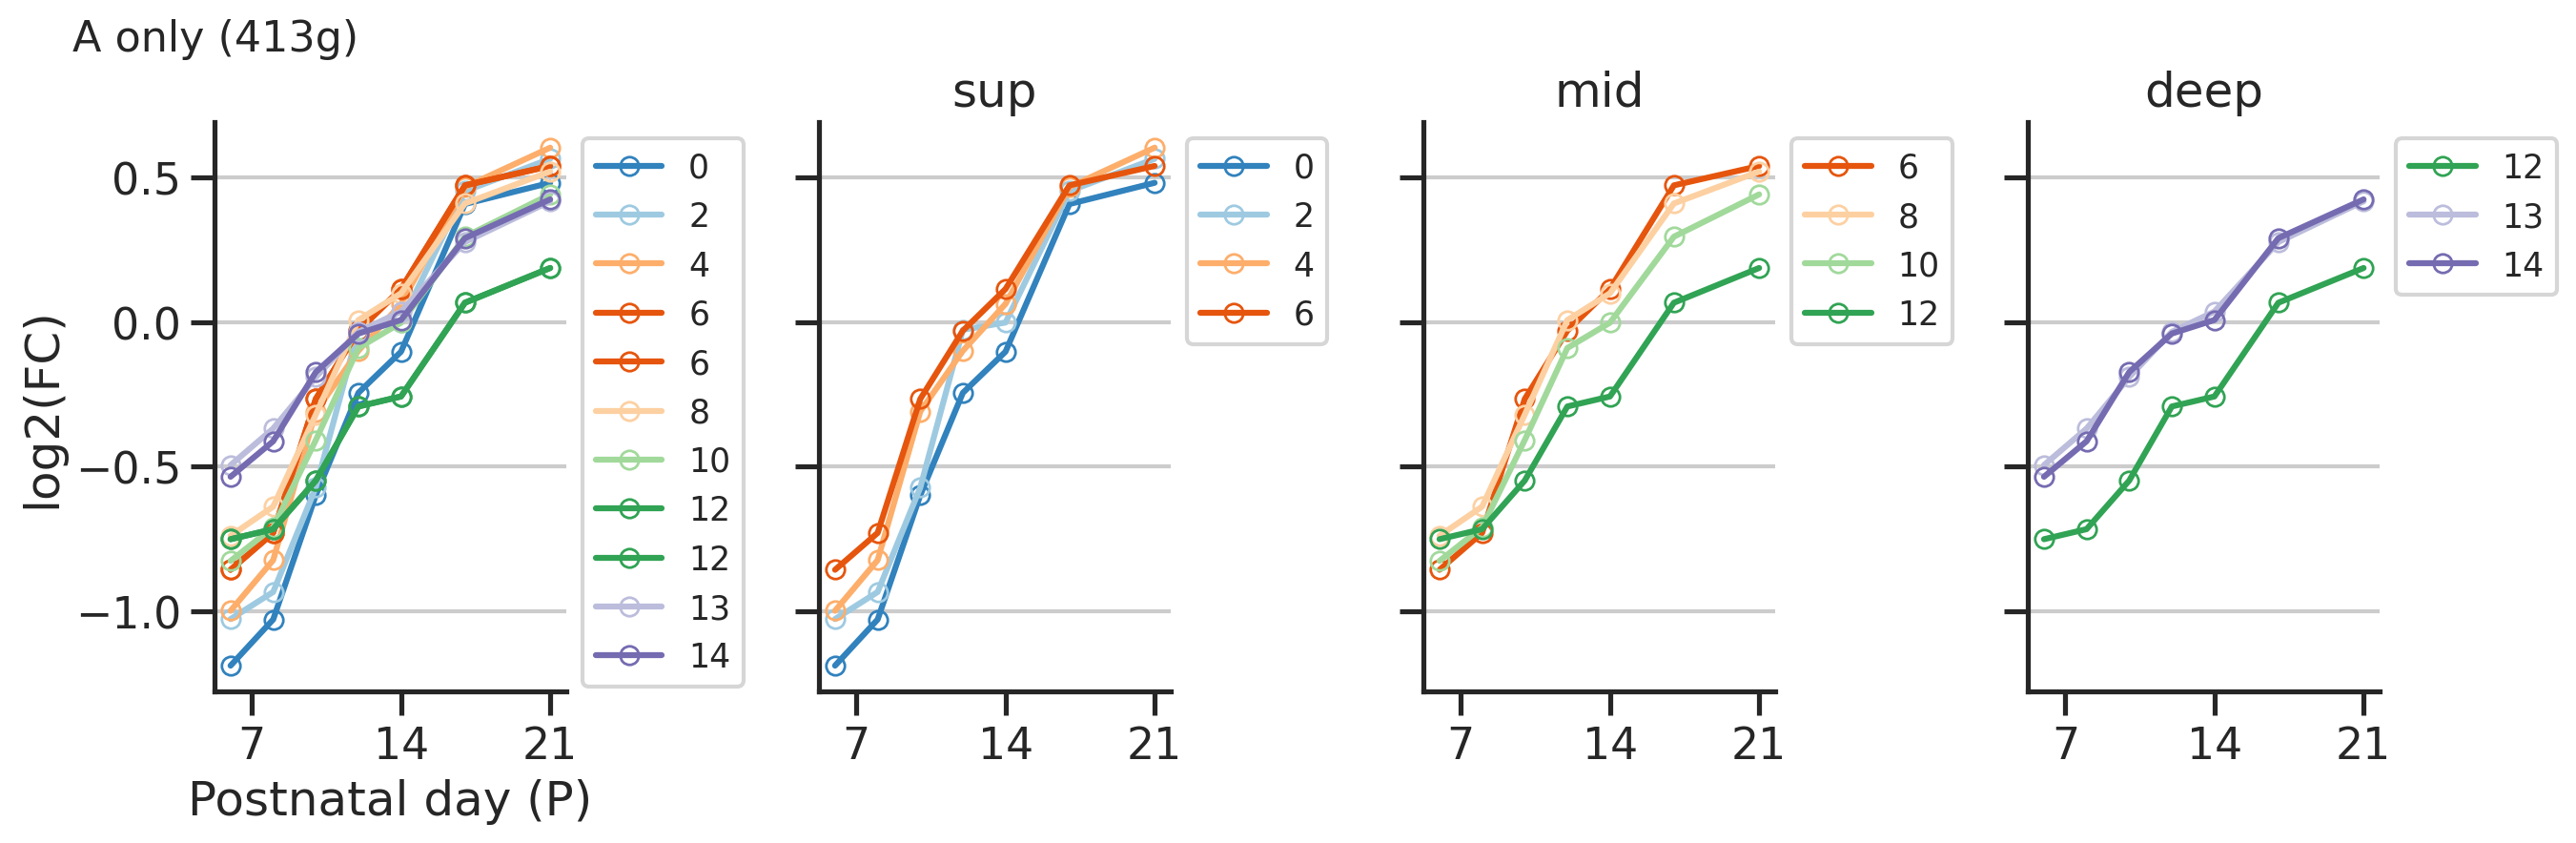

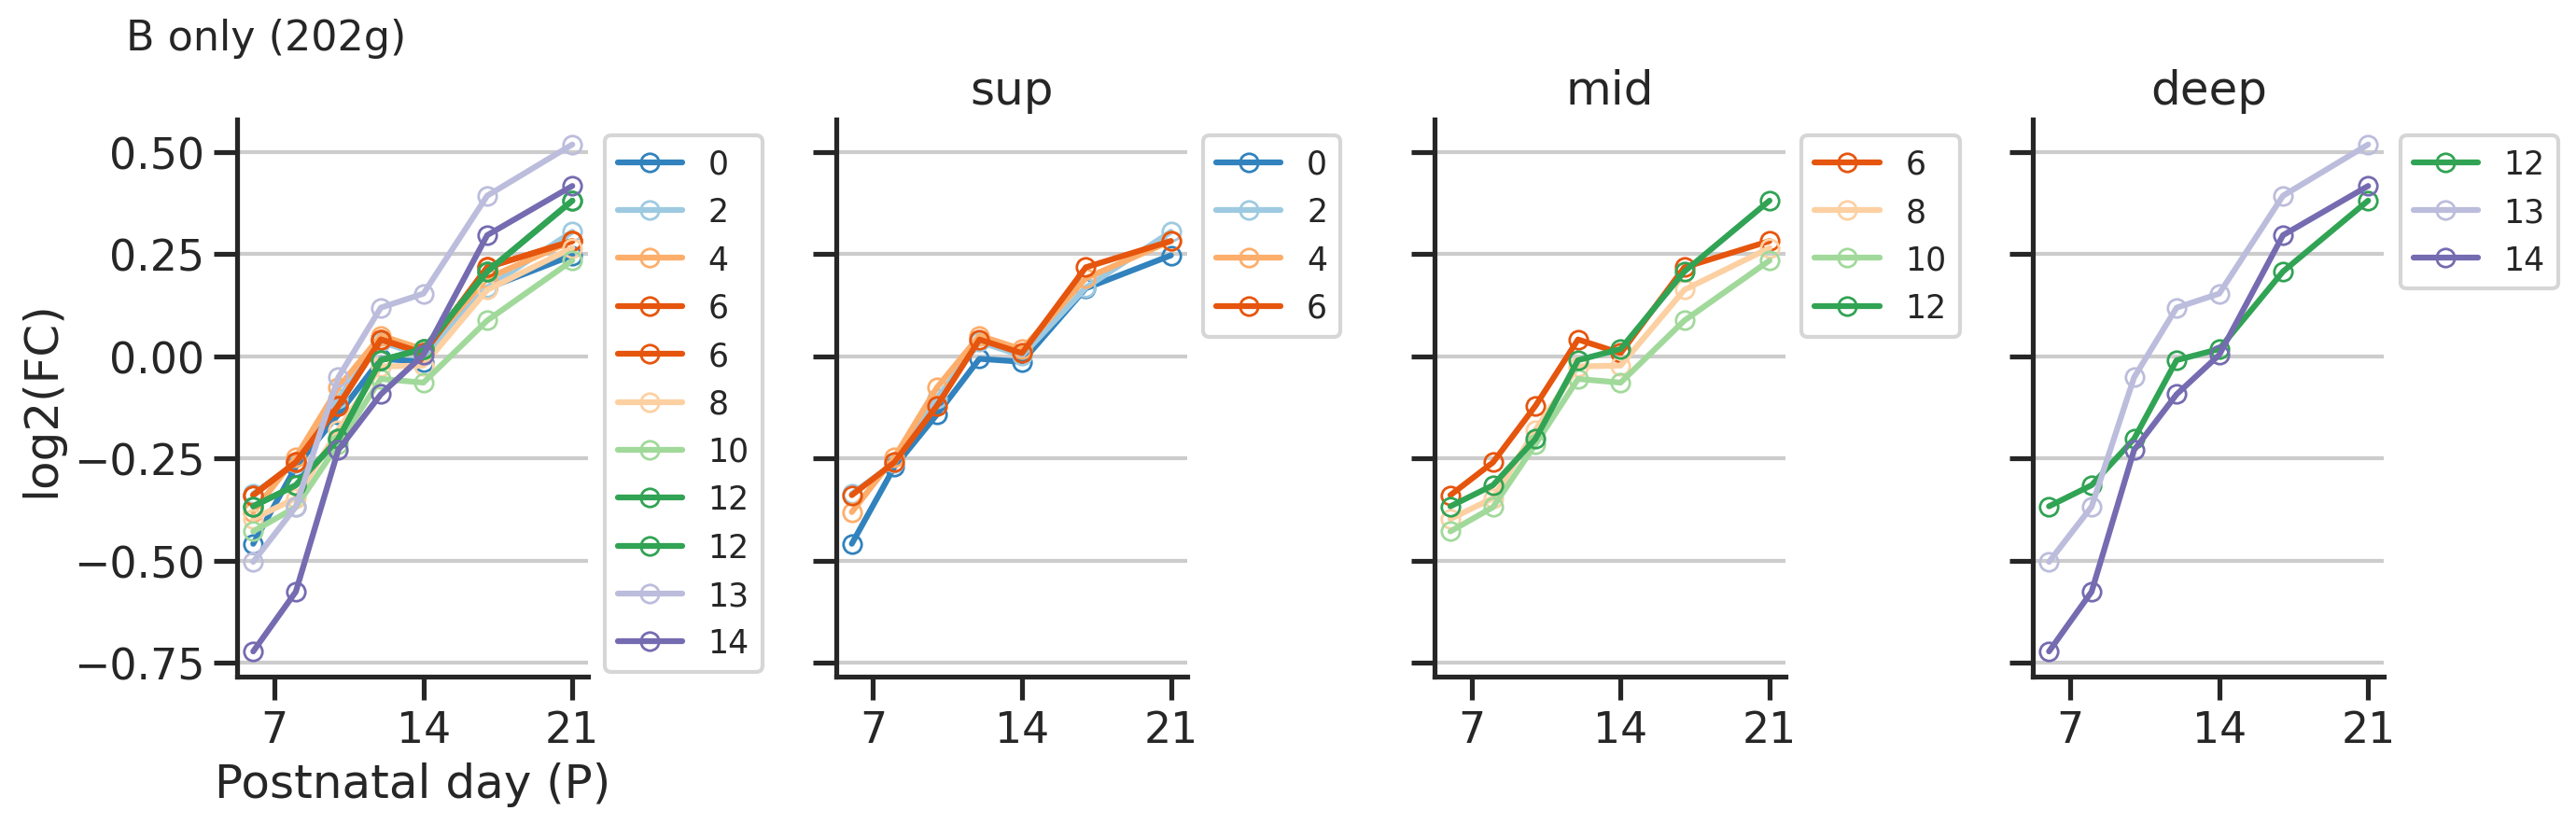

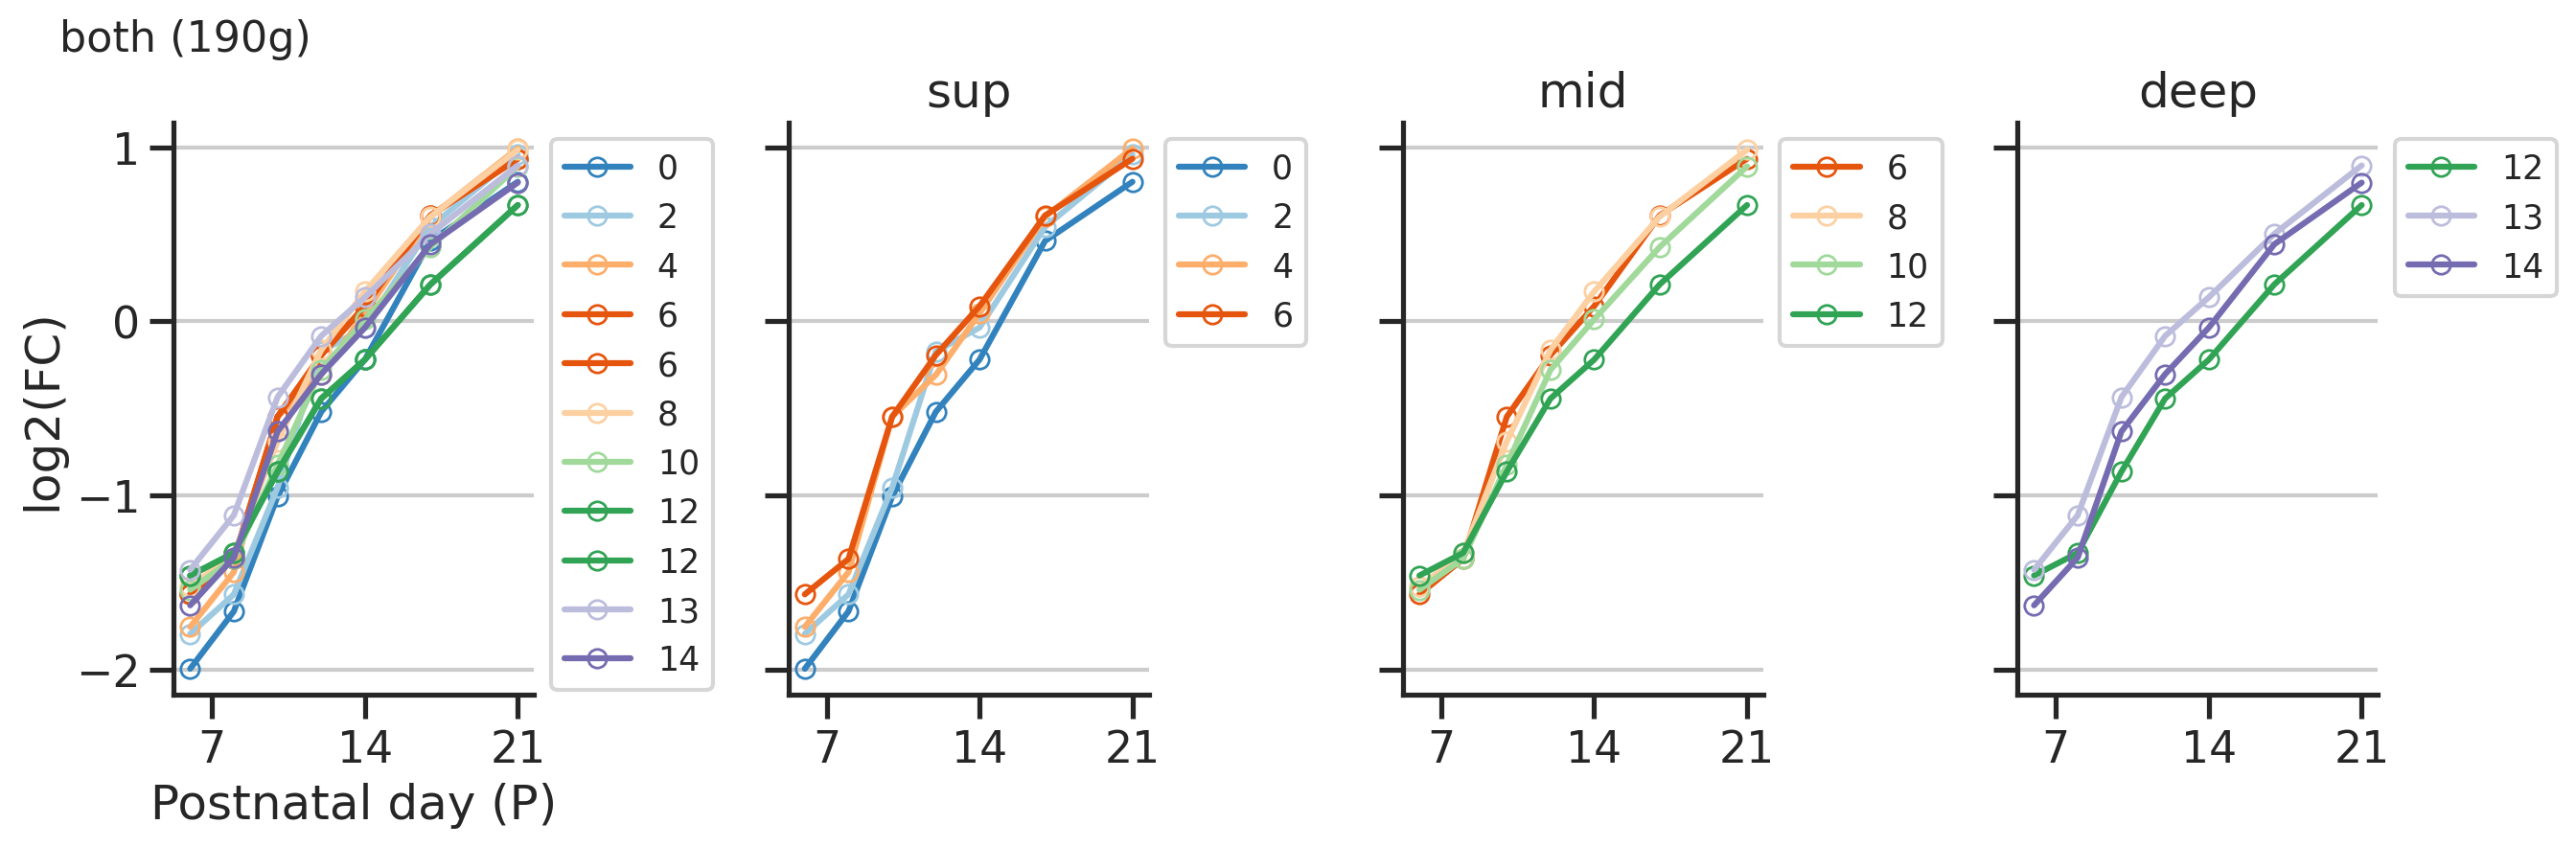

In [18]:
def get_nonoverlap(reg_genes_a, reg_genes_b):
    rg_a  = np.setdiff1d(reg_genes_a, reg_genes_b)
    rg_b  = np.setdiff1d(reg_genes_b, reg_genes_a)
    rg_ab = np.intersect1d(reg_genes_a, reg_genes_b)
    return rg_ab, rg_a, rg_b
    

rg_ab, rg_a, rg_b = get_nonoverlap(reg_genes1, reg_genes4)
for reg_name, reg_genes in zip(["A only", "B only", "both"], [rg_a, rg_b, rg_ab]):
    plot2(reg_name, baseline_gexp, reg_genes=reg_genes)
    

# Get L23ABC genes and redo

In [19]:
f = '/u/home/f/f7xiesnm/v1_multiome/table_s4_genes.csv'
df_abc = pd.read_csv(f, index_col=0)
df_abc

,cond,archetype,gene
22,P6,A,6530403H02Rik
10,P6,A,Acvr2a
11,P6,A,Ano3
65,P6,A,Asic2
7,P6,A,Atp2b4
...,...,...,...
1856,P21DR,C,Tox
1922,P21DR,C,Trpm3
1882,P21DR,C,Unc5d
1838,P21DR,C,Zfp385b


In [20]:
genes_l23  = df_abc['gene'].unique()
genes_l23a = df_abc[df_abc['archetype']=='A']['gene'].unique()
genes_l23b = df_abc[df_abc['archetype']=='B']['gene'].unique()
genes_l23c = df_abc[df_abc['archetype']=='C']['gene'].unique()
print(
      len(genes_l23),
      len(genes_l23a), 
      len(genes_l23b),
      len(genes_l23c),
     )

502 212 114 223


In [21]:
reg_name = 'Egr1++'
reg_genes1 = np.sort(df_scenic1[df_scenic1['Consensus_name']==reg_name]['Gene'].unique())
reg_genes2 = np.sort(df_scenic2[df_scenic2['Consensus_name']==reg_name]['Gene'].unique())
reg_genes3 = np.sort(df_scenic3[df_scenic3['Consensus_name']==reg_name]['Gene'].unique())
reg_genes4 = np.sort(df_scenic4[df_scenic4['Consensus_name']==reg_name]['Gene'].unique())

In [22]:
rg_1a = np.intersect1d(reg_genes1, genes_l23a)
rg_1b = np.intersect1d(reg_genes1, genes_l23b)
rg_1c = np.intersect1d(reg_genes1, genes_l23c)
rg_1o = np.setdiff1d(reg_genes1, genes_l23)
print(
      len(rg_1a),
      len(rg_1b), 
      len(rg_1c),
      len(rg_1o),
     )

19 39 45 514


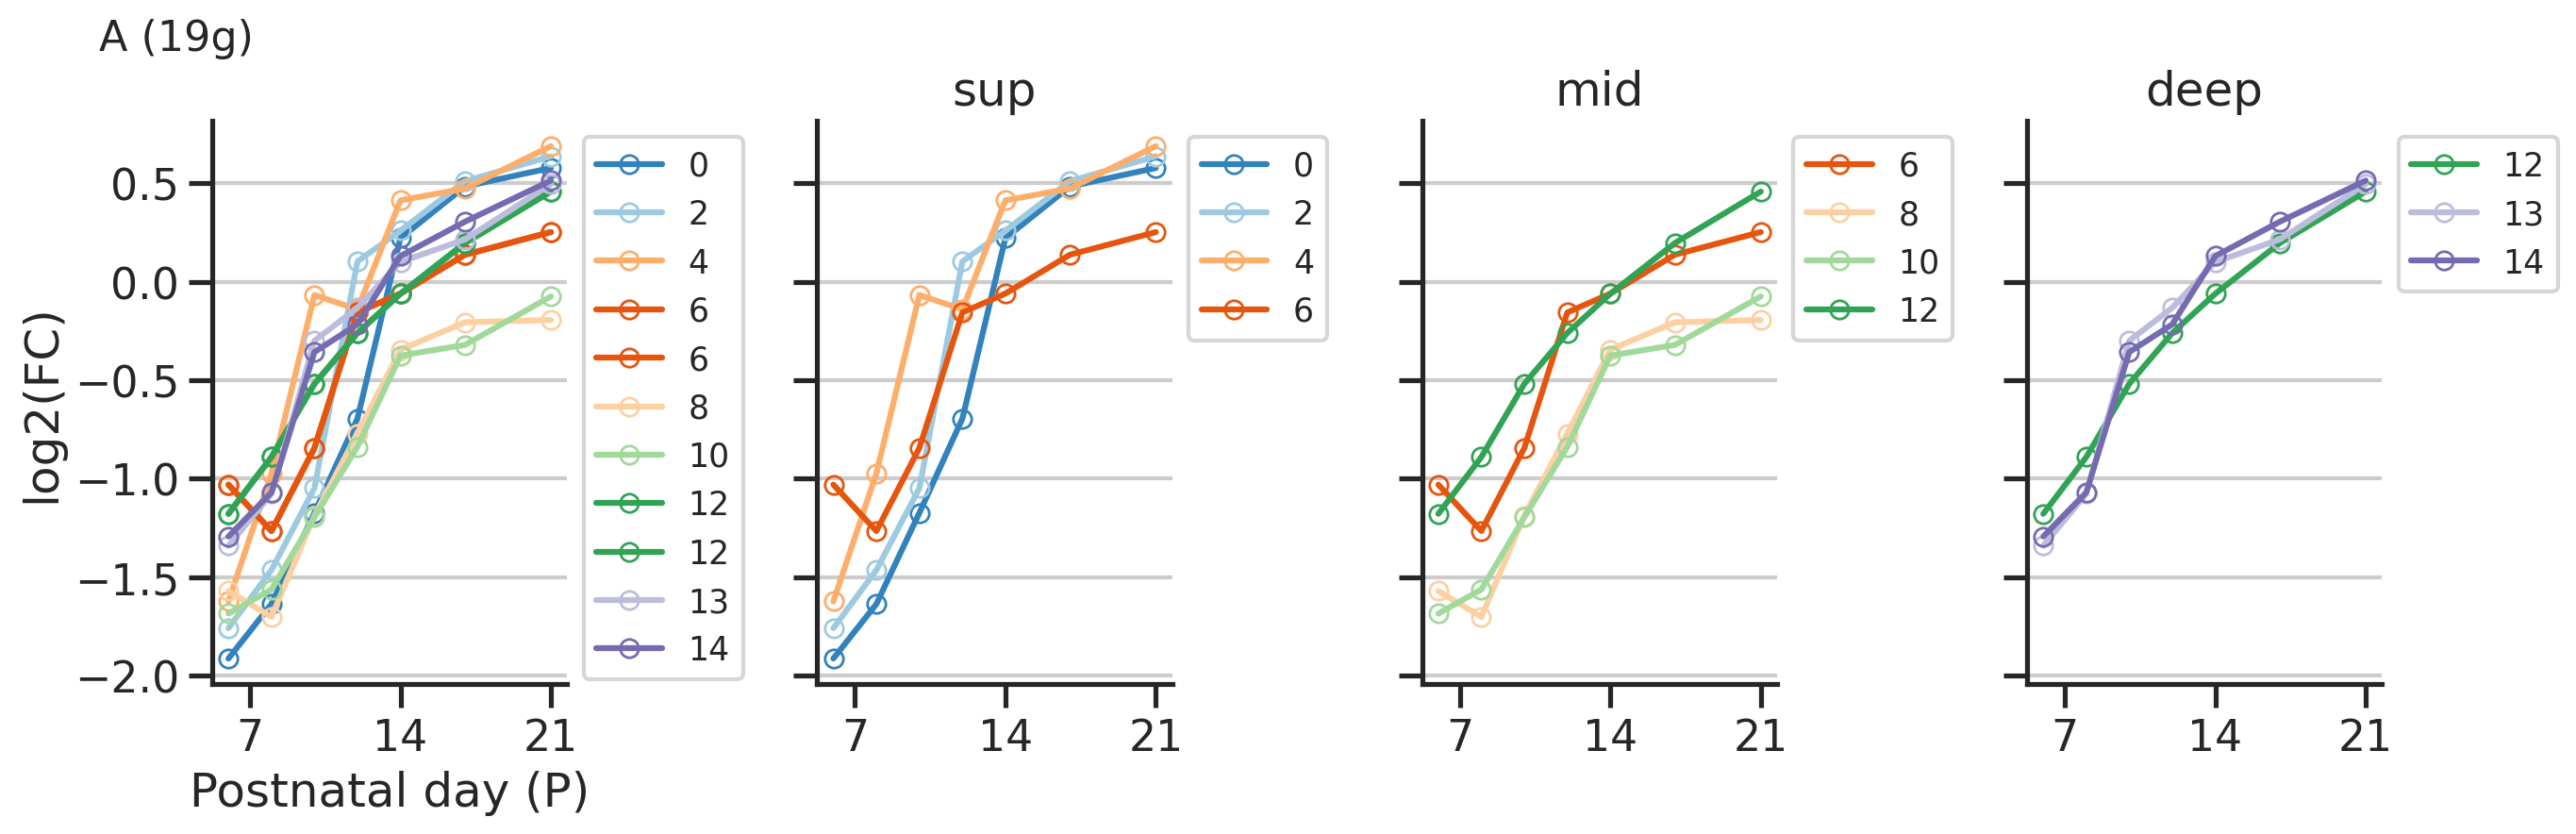

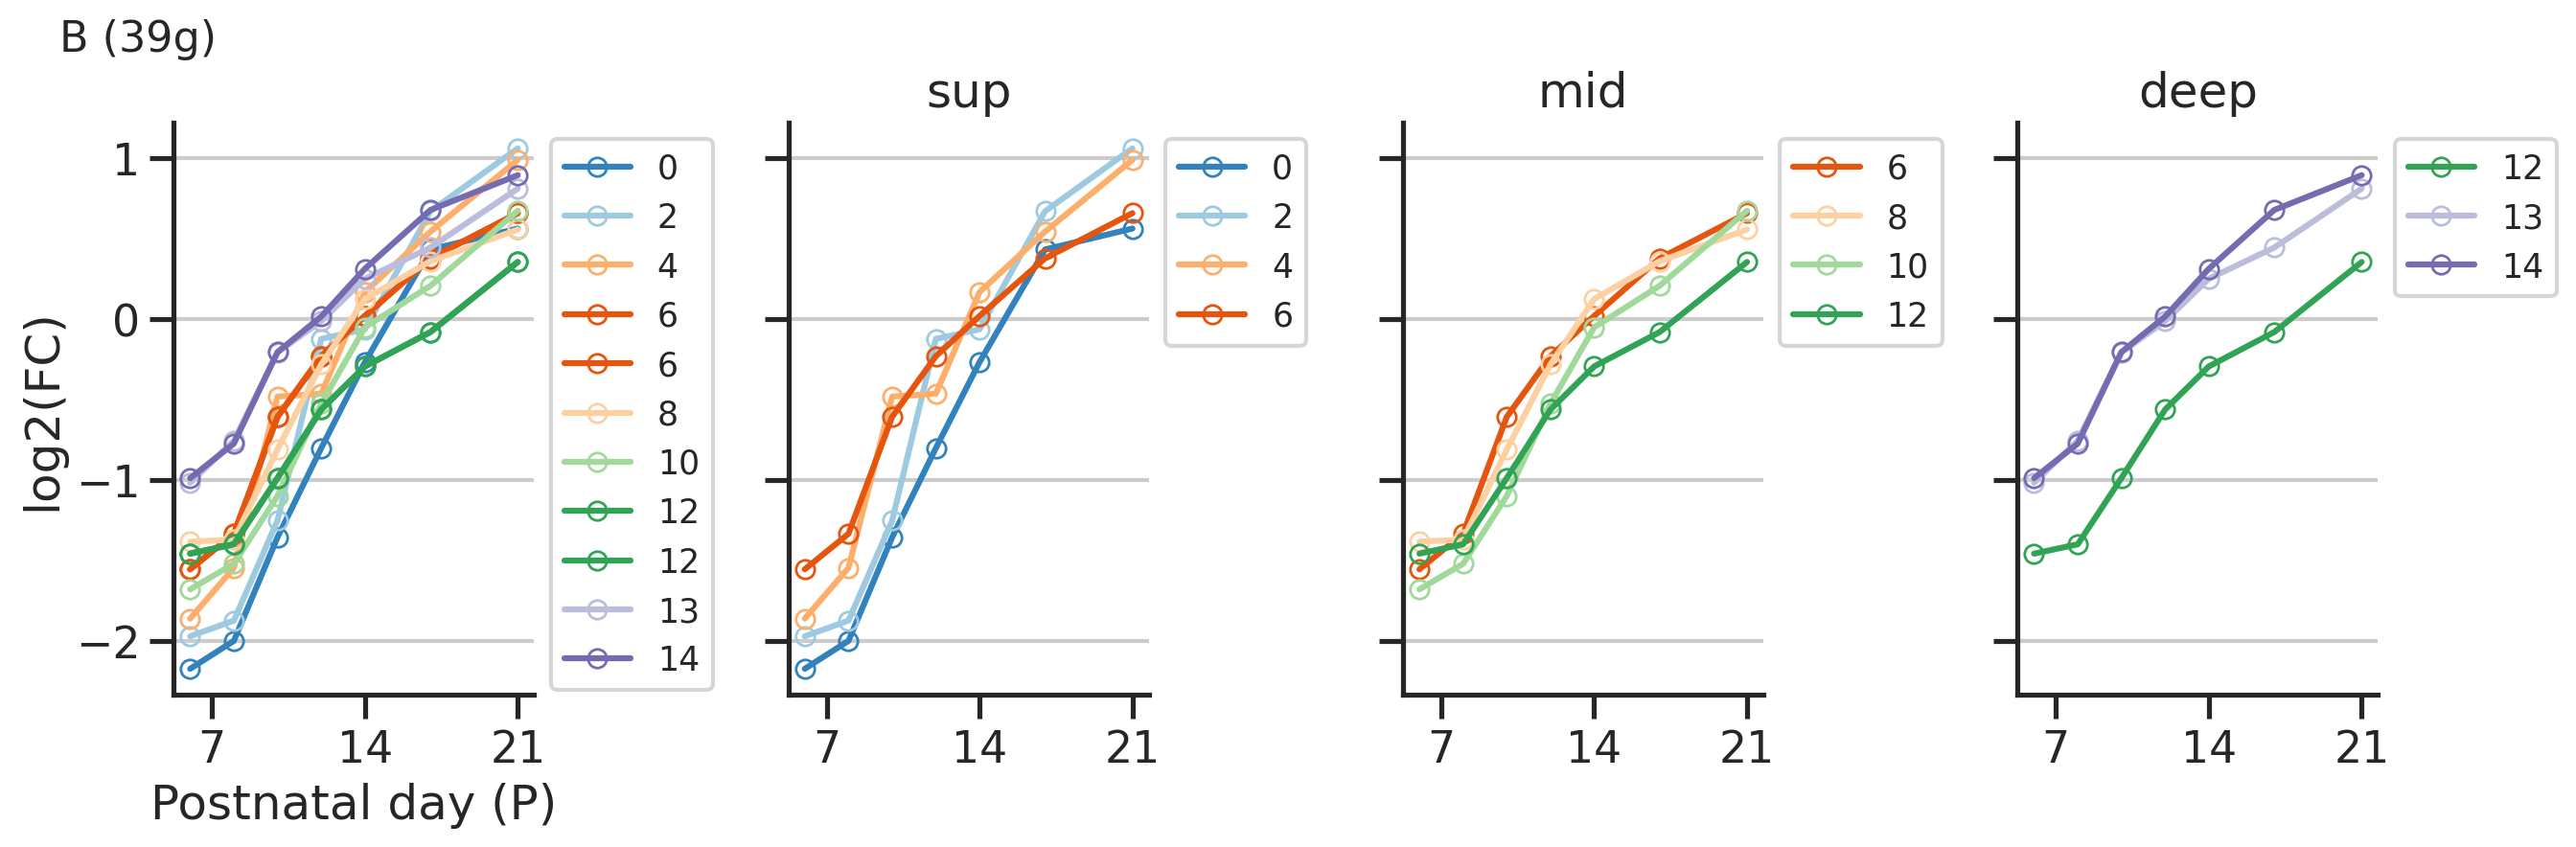

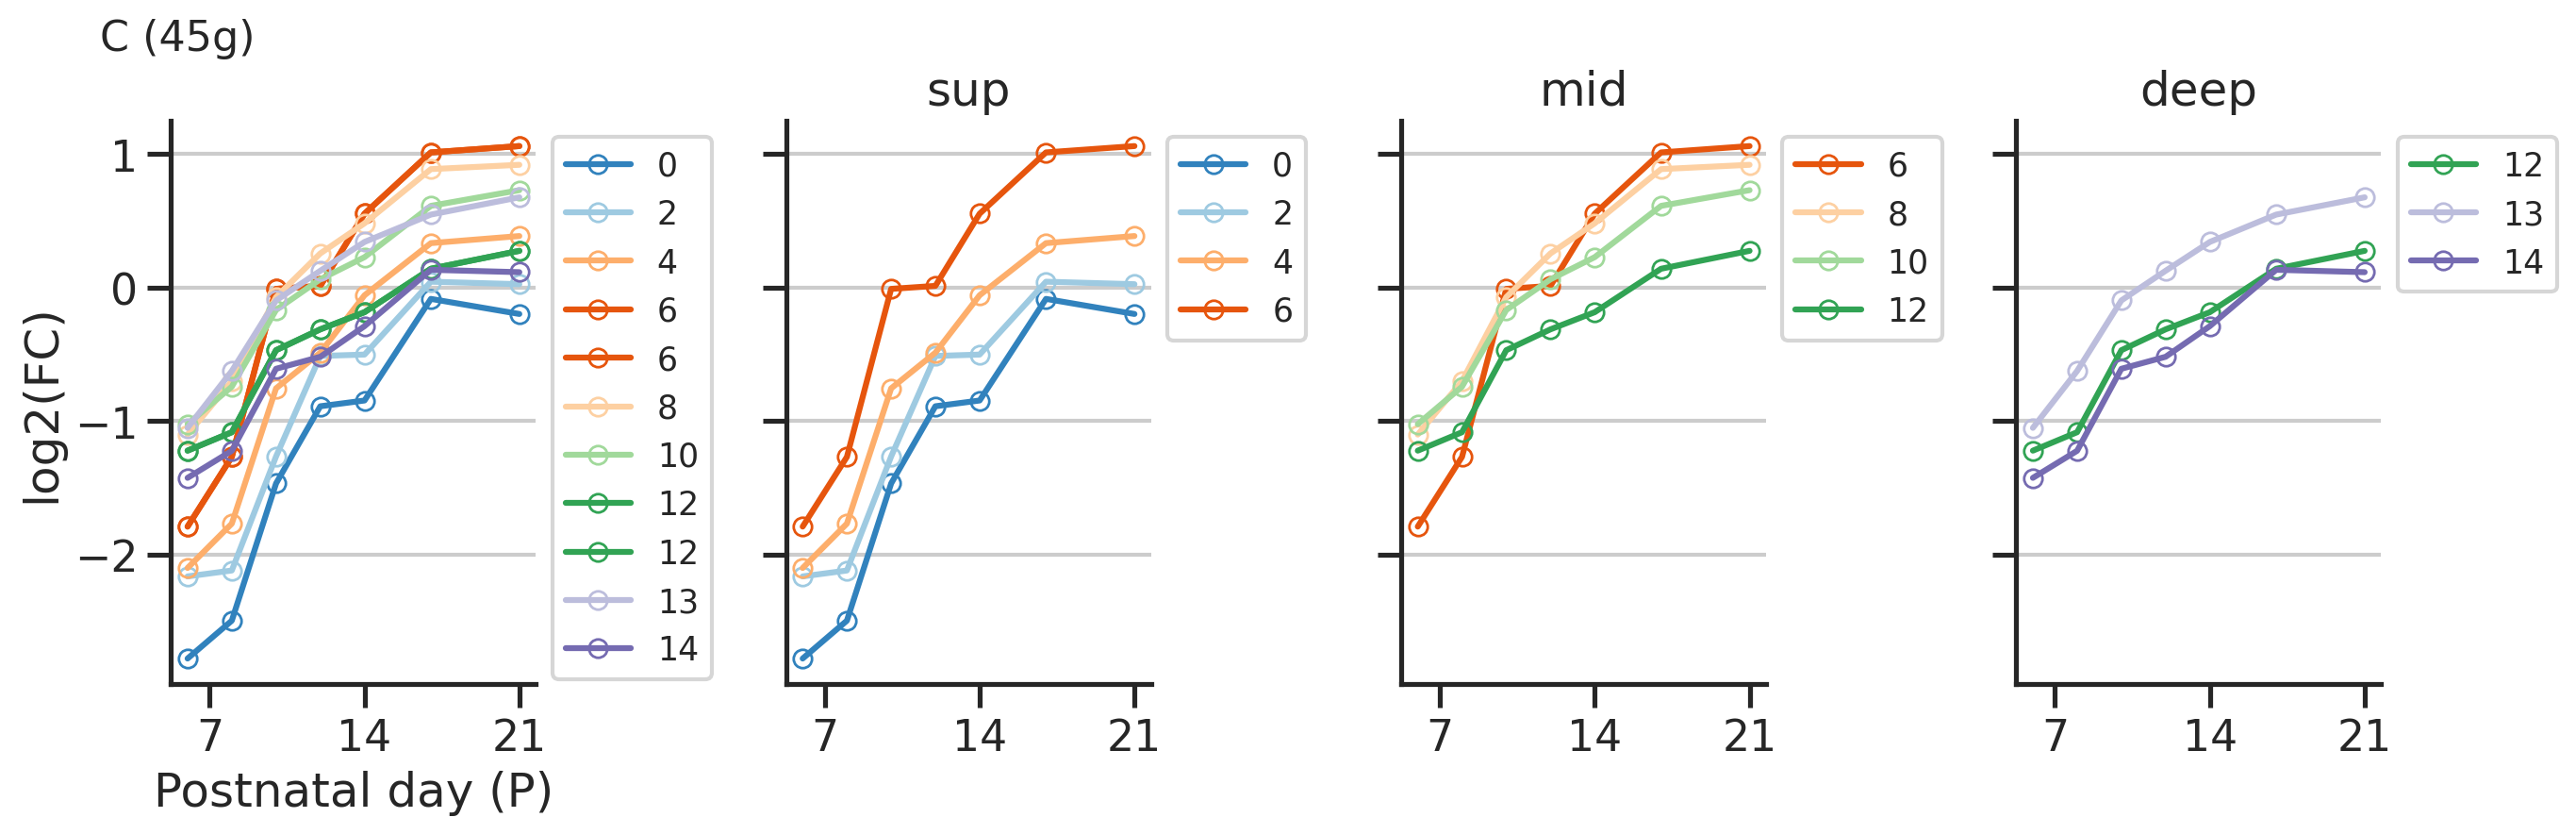

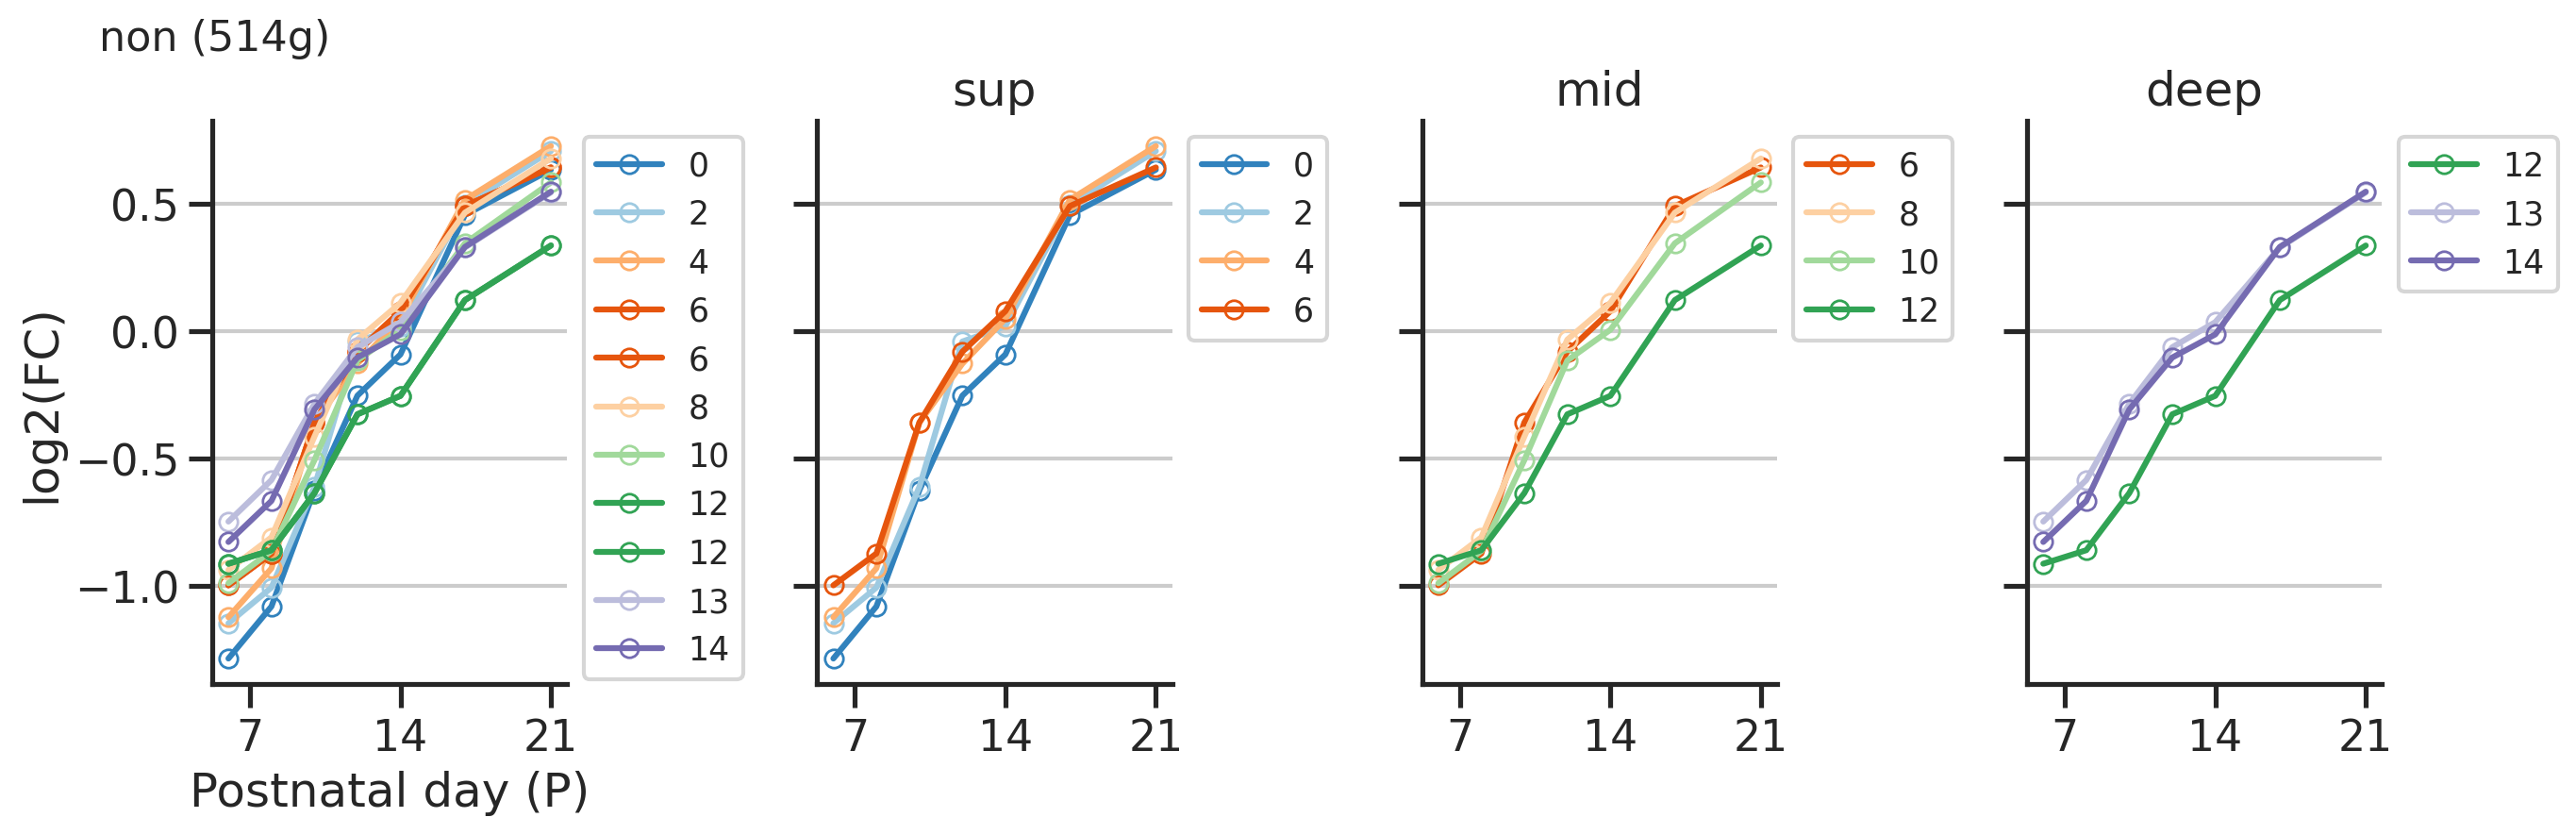

In [23]:
# for reg_name, reg_genes in zip(["B", "C", "non"], [rg_1b, rg_1c, rg_1o]):
#     plot2(reg_name, baseline_gexp, reg_genes=reg_genes)

for reg_name, reg_genes in zip(["A", "B", "C", "non"], [rg_1a, rg_1b, rg_1c, rg_1o]):
    plot2(reg_name, baseline_gexp, reg_genes=reg_genes)

# difference across time for each bin

In [24]:
qry_conds_idx = basicu.get_index_from_array(bt.conds, qry_conds)
print(qry_conds_idx)
qry_bt = bt.bt[qry_conds_idx]

[0 1 2 3 5 7 9]


In [25]:
qry_bt.shape

(7, 15, 16567)

In [26]:
import numpy as np

def variance_decomposition(arr):
    # 1. Total Variance
    total_var = np.var(arr)
    
    # 2. Variance of the Row Means
    # We take the mean of each row, then find the variance of those means
    row_means = np.mean(arr, axis=1)
    row_var = np.var(row_means)
    
    # 3. Variance of the Column Means
    col_means = np.mean(arr, axis=0)
    col_var = np.var(col_means)
    
    # Calculate fractions
    frac_rows = row_var / total_var
    frac_cols = col_var / total_var
    
    return total_var, frac_rows, frac_cols

total_var, r_frac, c_frac = variance_decomposition(bt.bt[:,:,0])
print(f"Fraction of variance from Rows: {r_frac:.1%}")
print(f"Fraction of variance from Cols: {c_frac:.1%}")

Fraction of variance from Rows: 19.6%
Fraction of variance from Cols: 70.2%


In [27]:
total_vars = []
time_fracs = []
type_fracs = []
for i in range(qry_bt.shape[2]):
    total_var, time_frac, type_frac = variance_decomposition(qry_bt[:,:,i])
    total_vars.append(total_var)
    time_fracs.append(time_frac)
    type_fracs.append(type_frac)
    

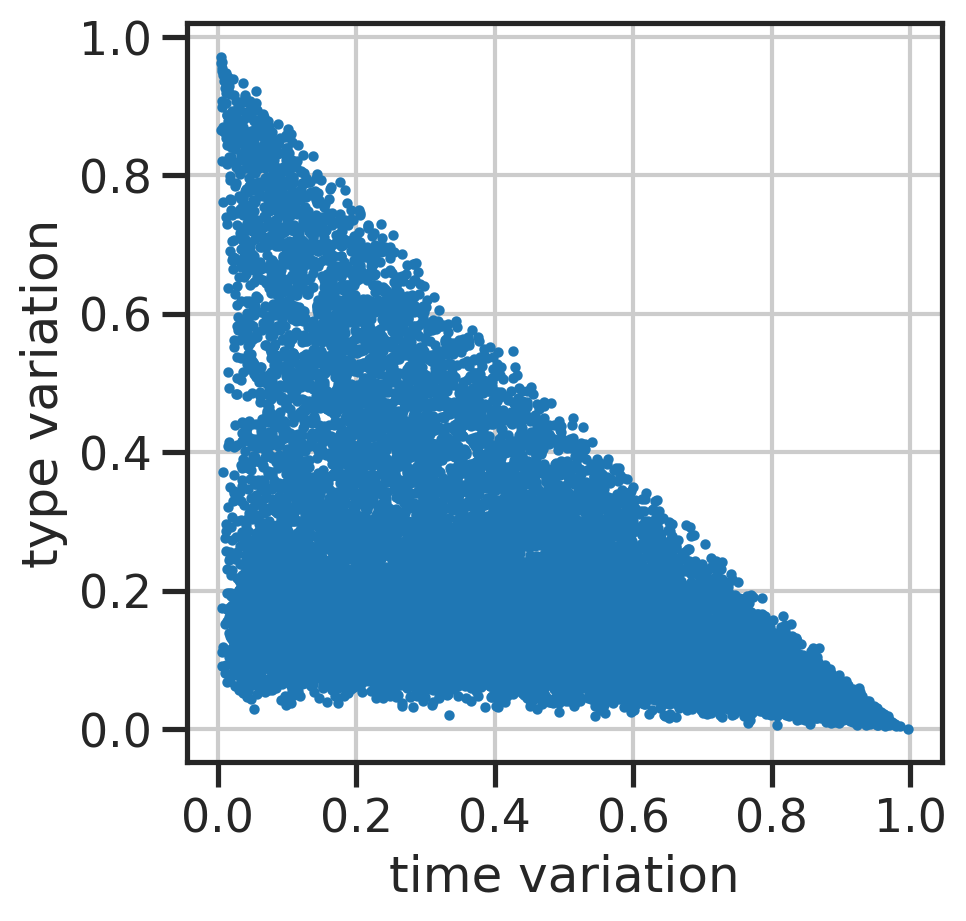

In [28]:
fig, ax = plt.subplots()
ax.scatter(time_fracs, type_fracs, s=5)
ax.set_aspect('equal')
ax.set_xticks(np.linspace(0,1,6))
ax.set_yticks(np.linspace(0,1,6))
ax.set_xlabel('time variation')
ax.set_ylabel('type variation')
plt.show()


In [29]:
from sklearn.metrics import pairwise_distances

nndists_mat = []
for i in range(qry_bt.shape[0]):
    X = qry_bt[i]
    # dists = pairwise_distances(X, metric='cosine') # This returns the square matrix directly
    dists = pairwise_distances(X, metric='euclidean') # This returns the square matrix directly
    nndists = np.sort(dists, axis=0)[1]
    nndists_mat.append(nndists)
nndists_mat = np.array(nndists_mat)

In [30]:
toptype_idx = np.argsort(type_fracs)[::-1]
bt.genes[toptype_idx]

array(['Osr1', 'Adam18', 'Cux2', ..., 'Rac3', 'Tubb2b', 'Xist'],
      dtype='<U14')

In [31]:
toptime_idx = np.argsort(time_fracs)[::-1]
bt.genes[toptime_idx]

array(['Xist', 'Tubb2b', 'Rac3', ..., 'Osr1', 'Nell2', 'Cux2'],
      dtype='<U14')

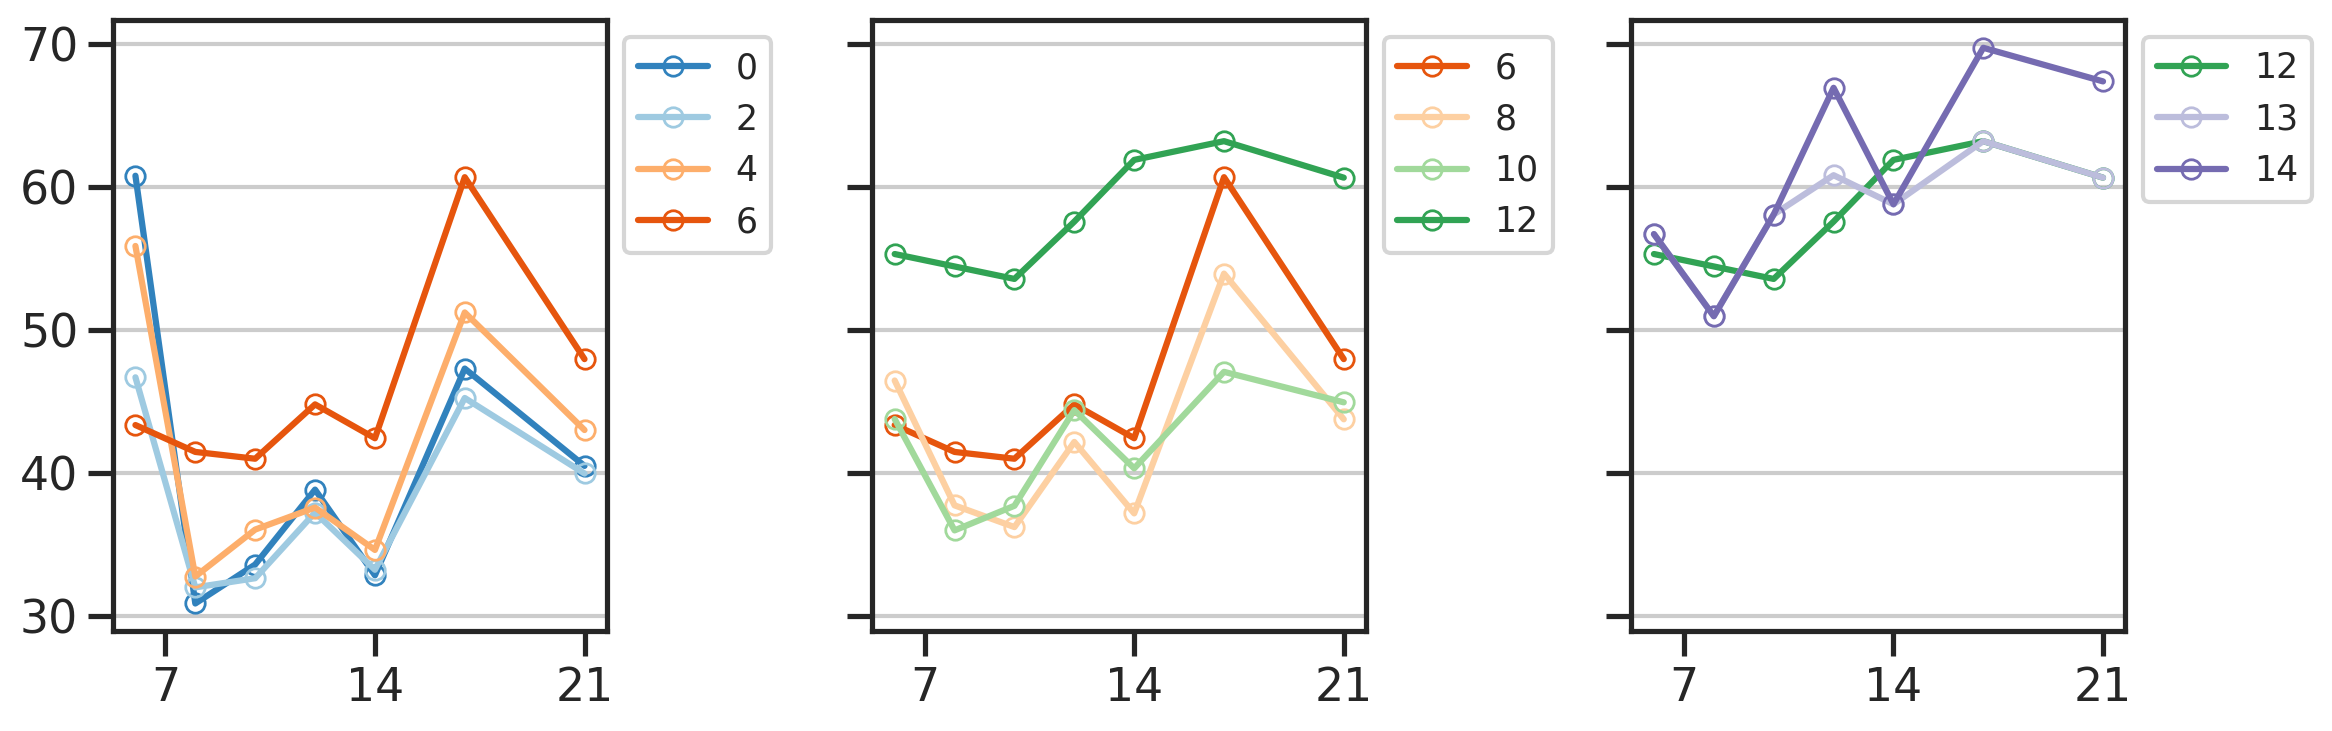

In [32]:
fig, axs = plt.subplots(1,3,figsize=(3*4,1*4), sharex=True, sharey=True)
ax = axs[0]
ax.grid(axis='x')
for num, i in enumerate([0,2,4,6]):
    color = type_colors_list[0][num]
    ax.plot(qry_times, nndists_mat[:,i], 
            '-o', 
            markerfacecolor='none', markersize=7,
            color=color, 
            label=i)
    ax.legend(bbox_to_anchor=(1,1), loc='upper left', fontsize='x-small')
    
ax = axs[1]
ax.grid(axis='x')
for num, i in enumerate([6,8,10,12]):
    color = type_colors_list[1][num]
    ax.plot(qry_times, nndists_mat[:,i], 
            '-o', 
            markerfacecolor='none', markersize=7,
            color=color, 
            label=i)
    ax.legend(bbox_to_anchor=(1,1), loc='upper left', fontsize='x-small')
    
ax = axs[2]
ax.grid(axis='x')
for num, i in enumerate([12,13,14]):
    color = type_colors_list[2][num]
    ax.plot(qry_times, nndists_mat[:,i], 
            '-o', 
            markerfacecolor='none', markersize=7,
            color=color, 
            label=i)
    ax.legend(bbox_to_anchor=(1,1), loc='upper left', fontsize='x-small')
    
# ax.set_ylim(ymin=0)
ax.set_xticks([7,14,21,])
fig.tight_layout()
plt.show()

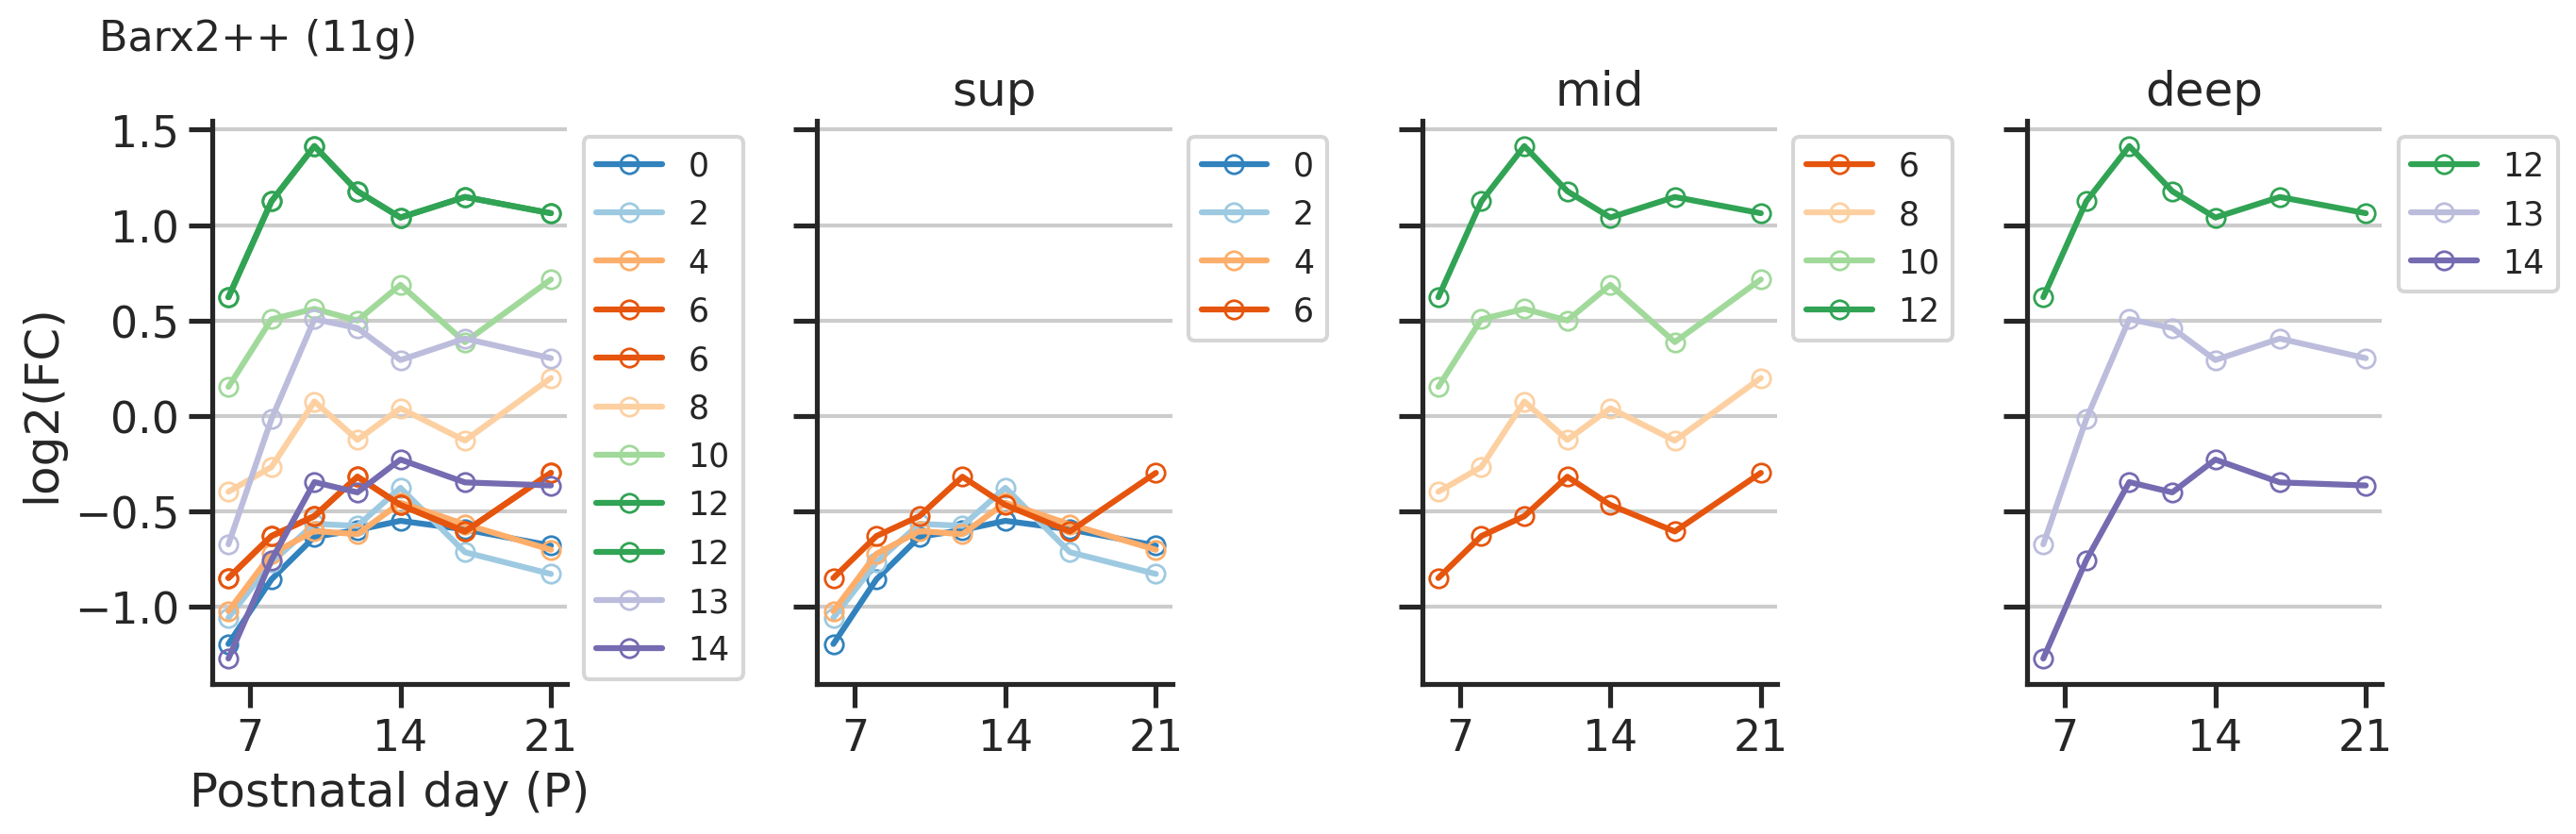

In [33]:
for reg_name in ['Barx2++']:
    plot2(reg_name, baseline_gexp, df_scenic=df_scenic2)

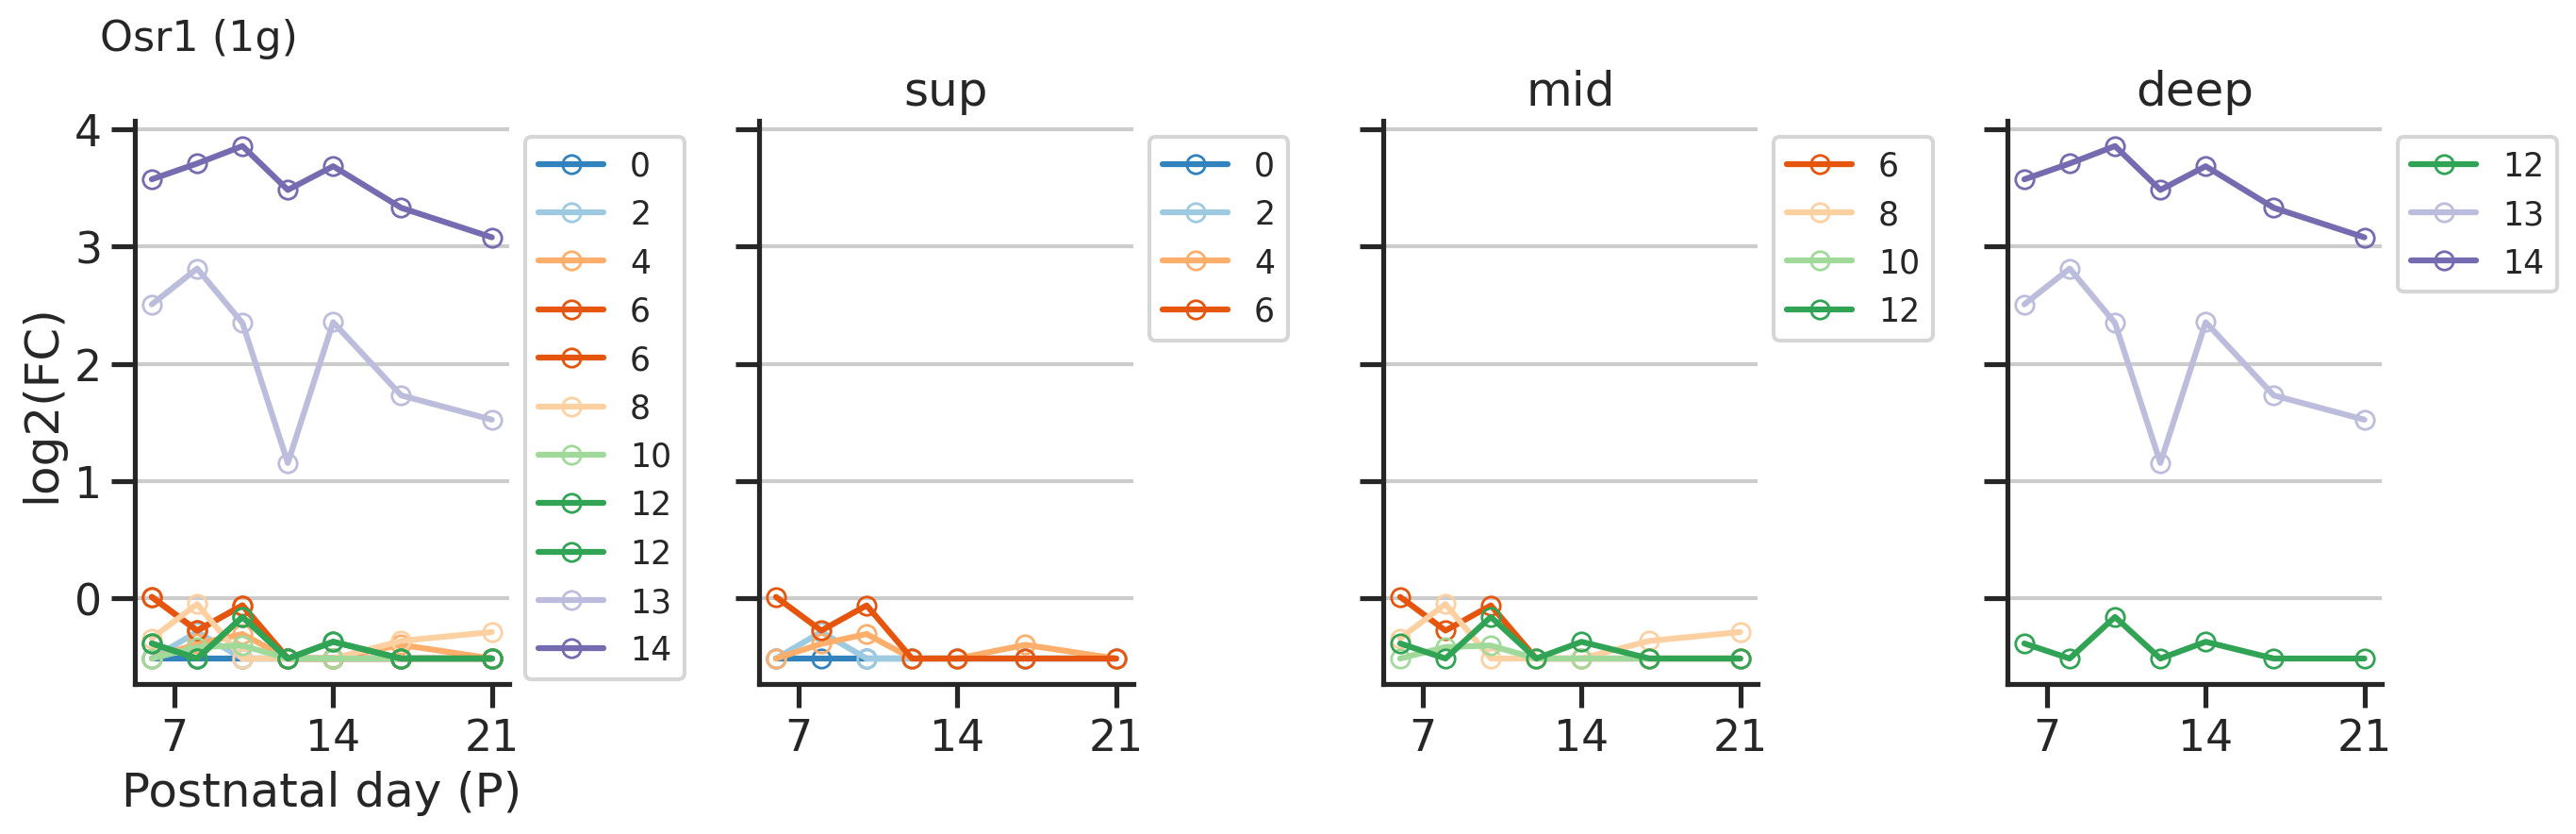

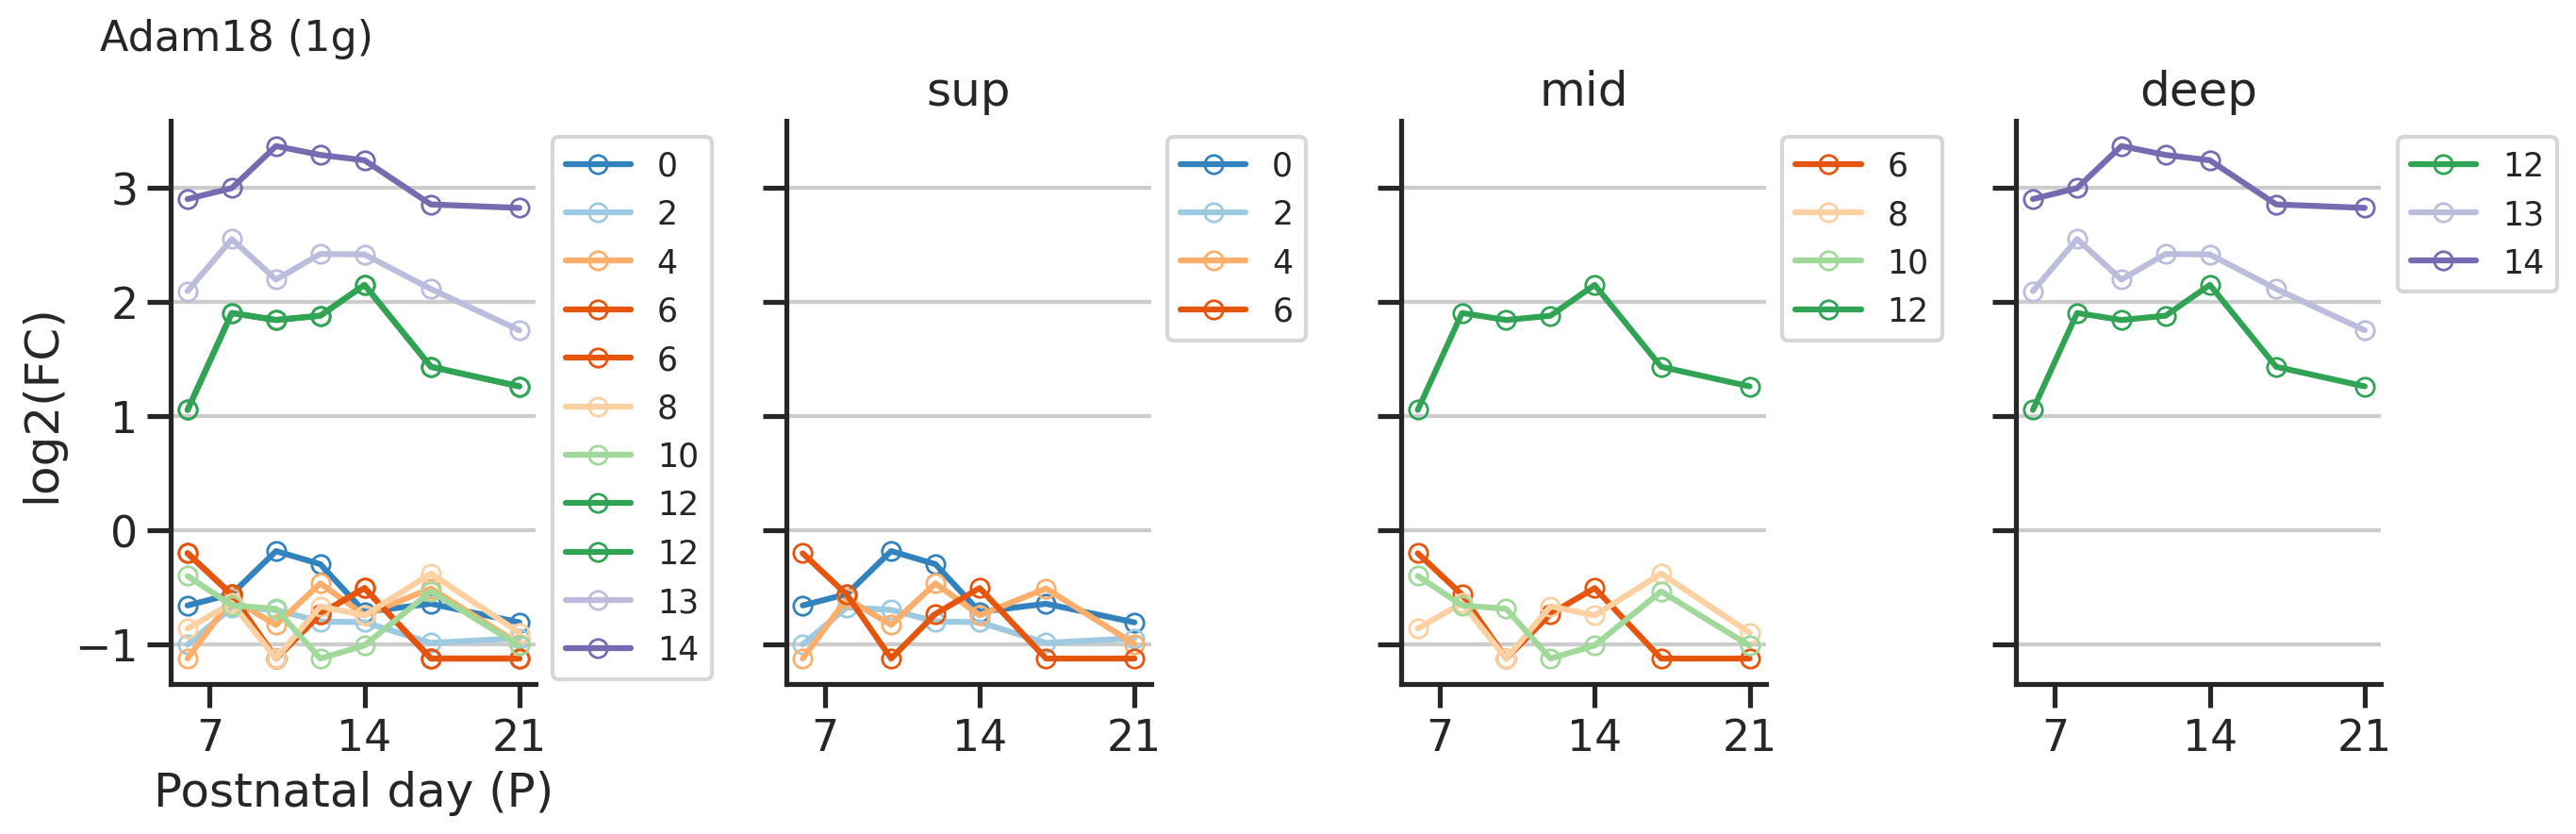

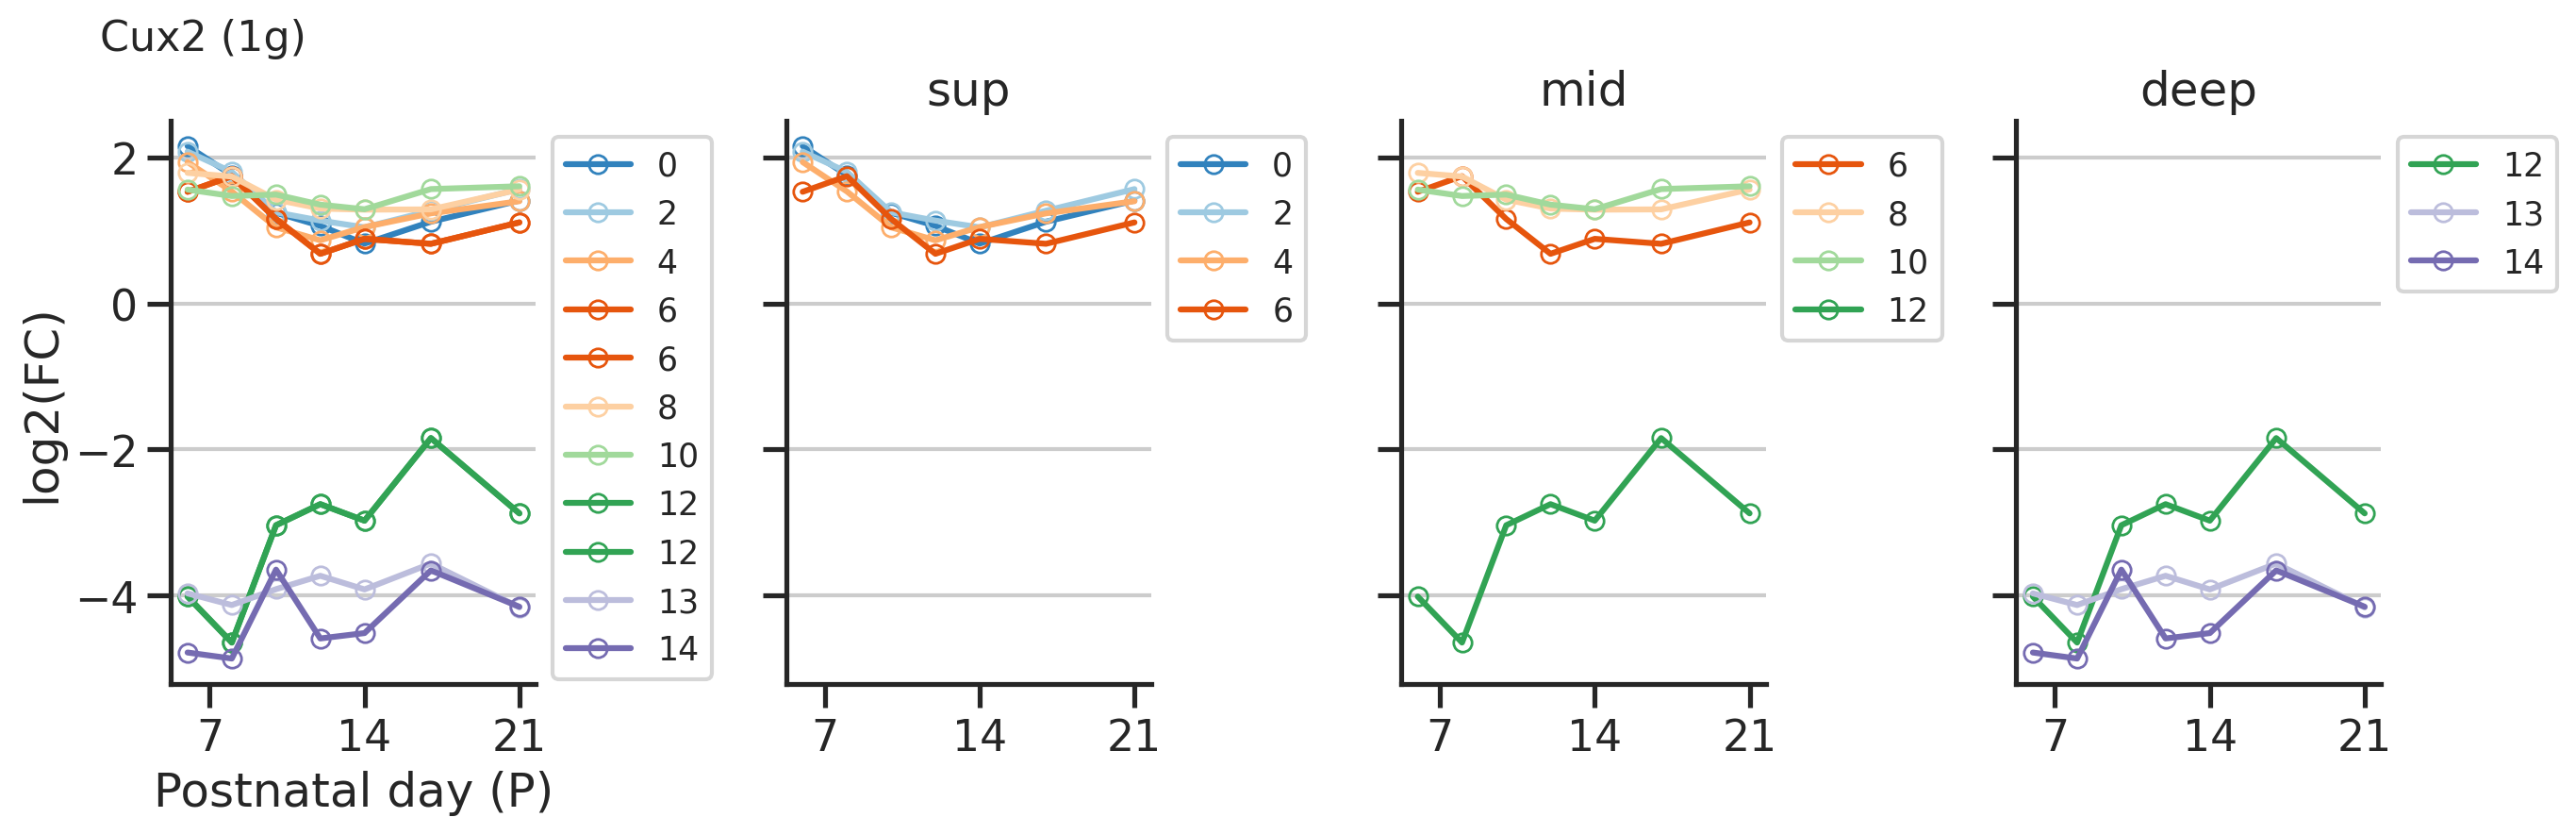

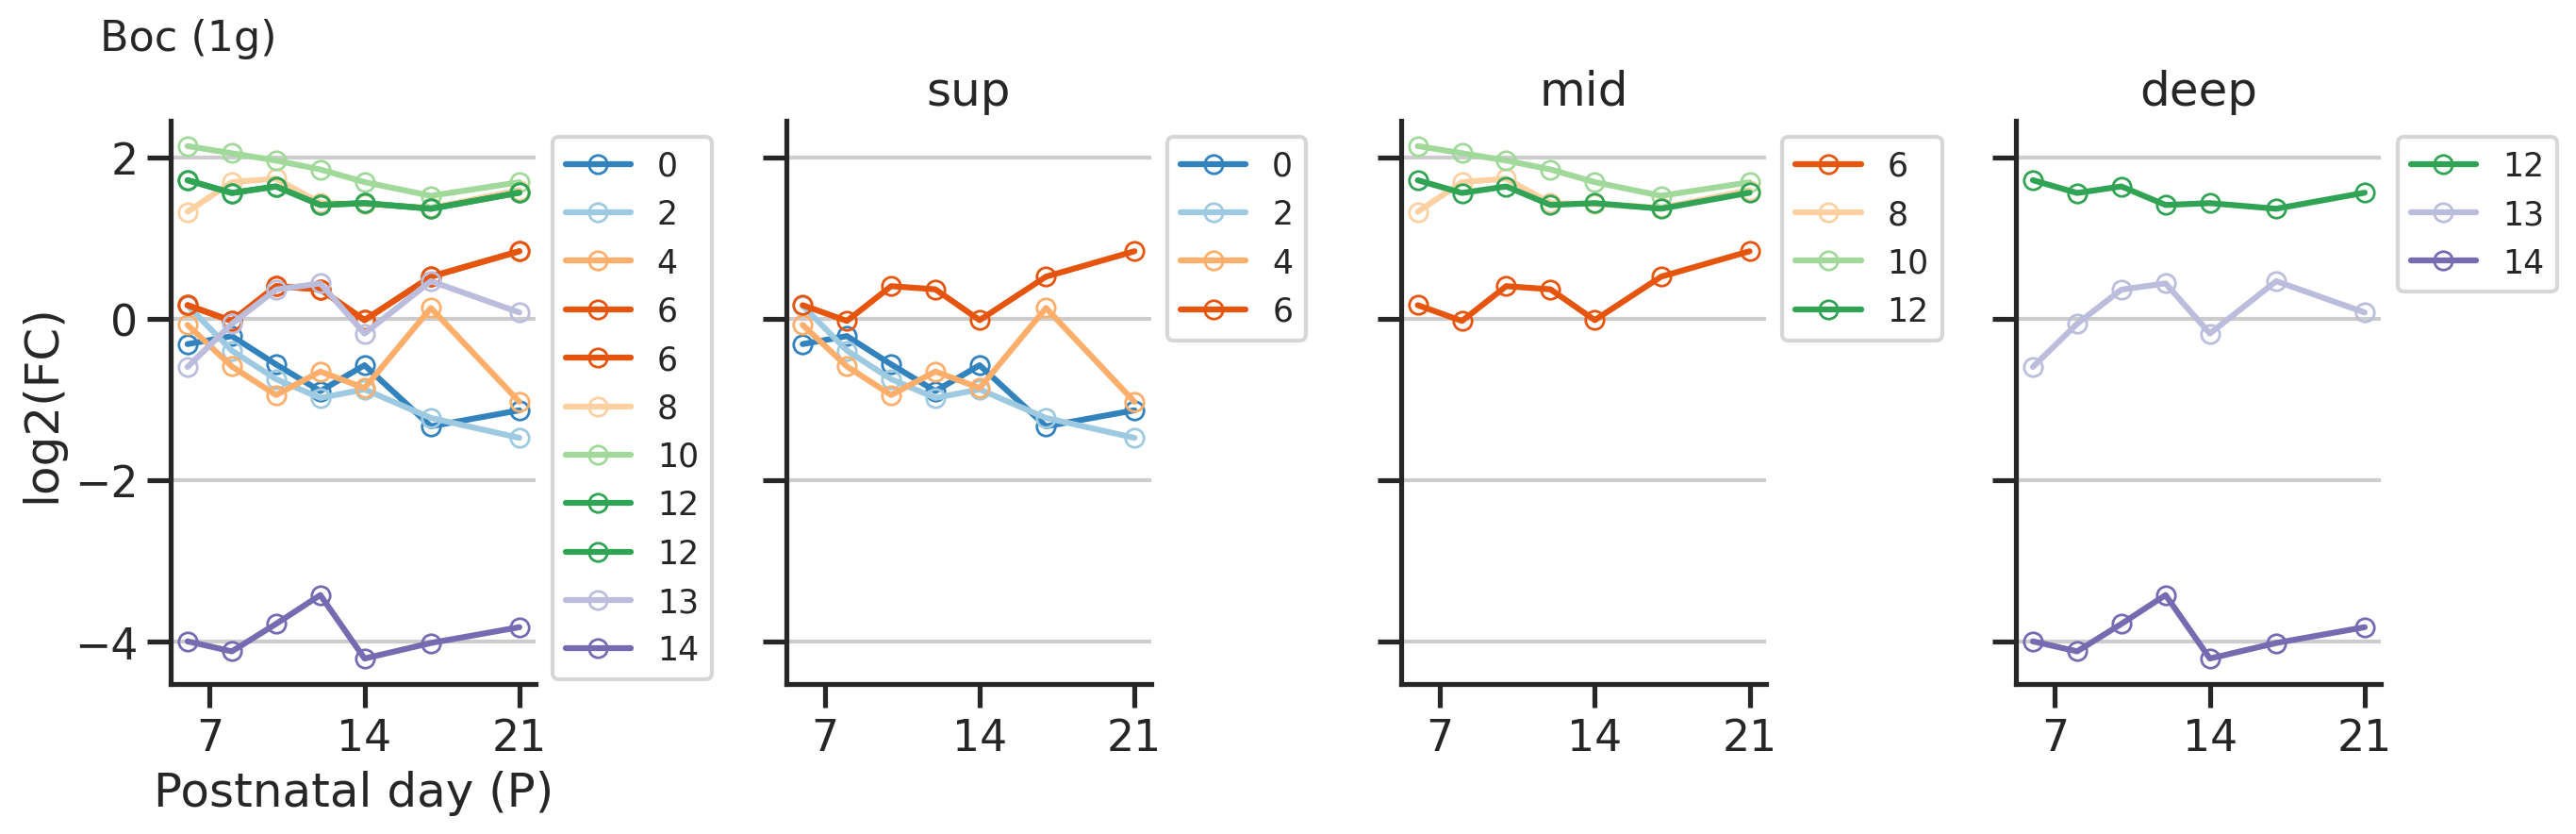

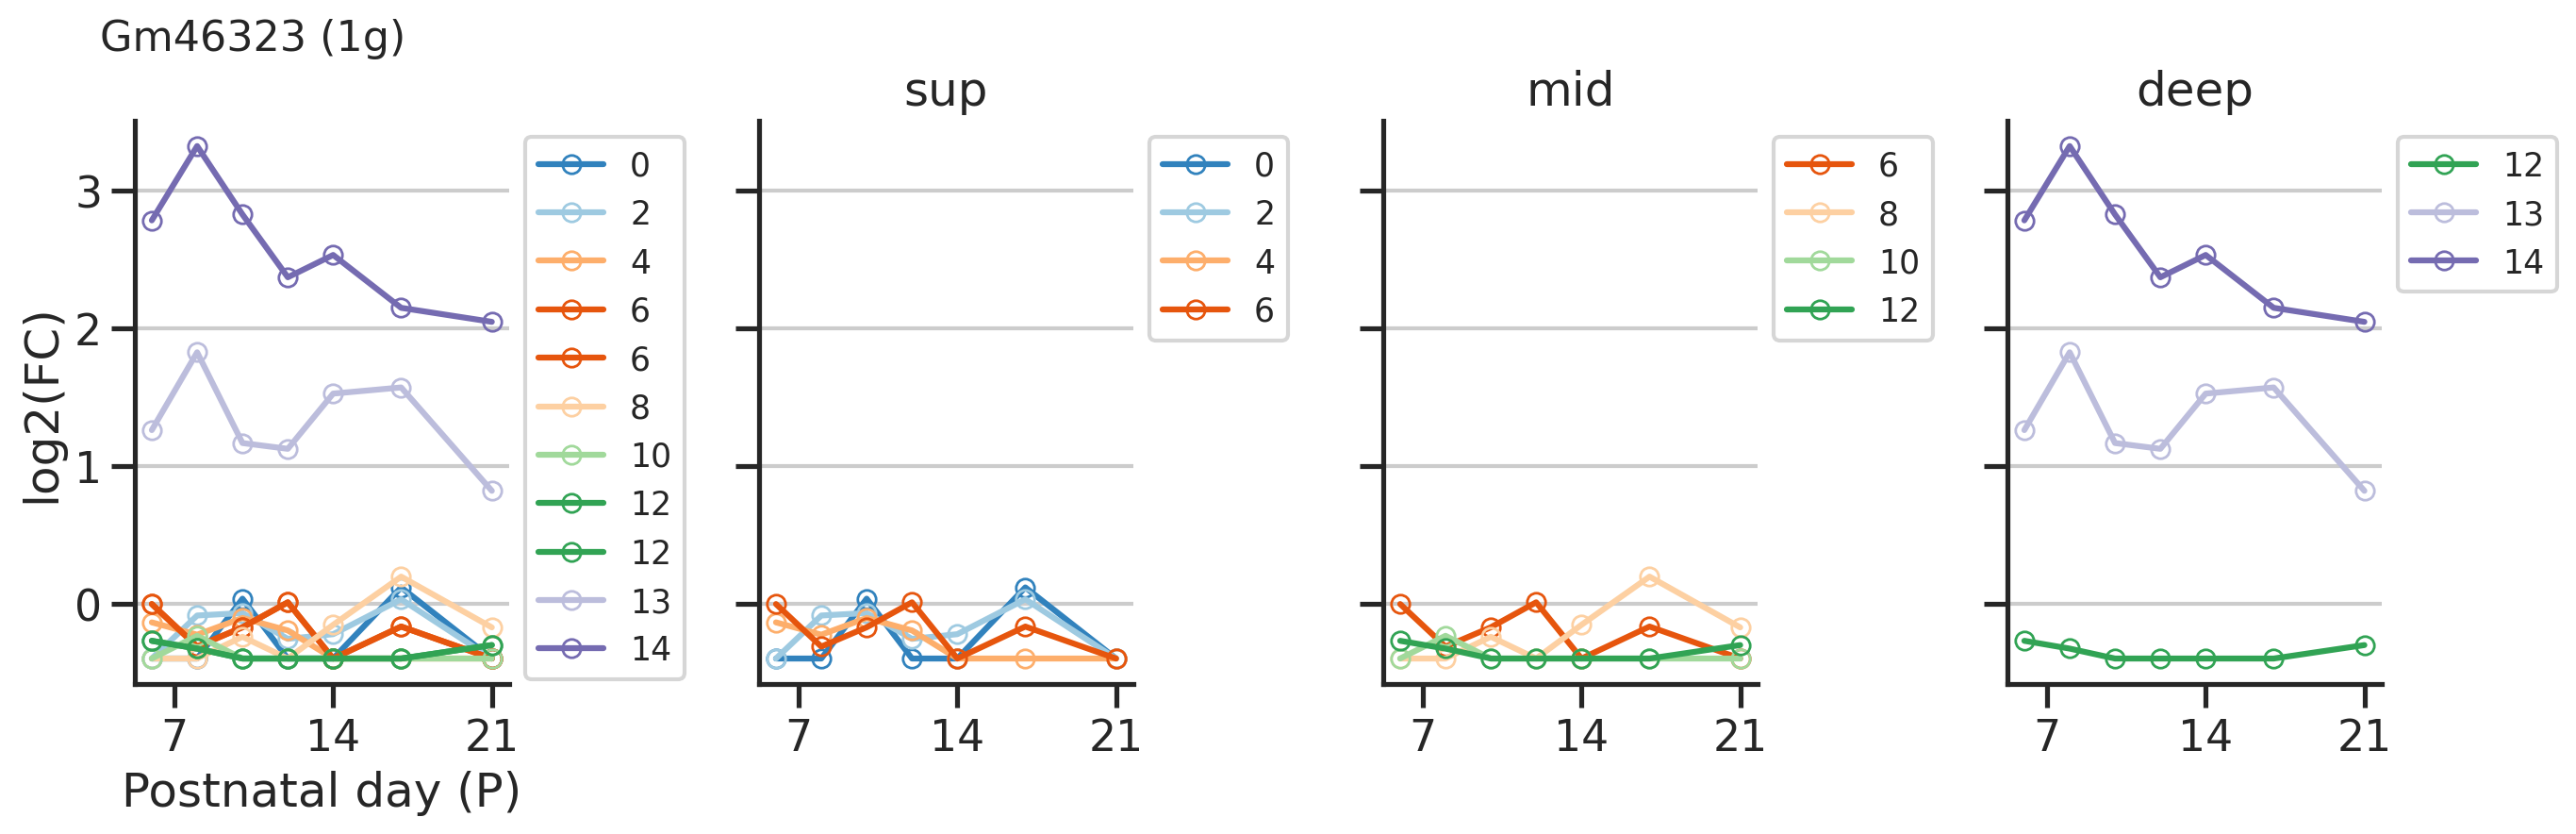

In [34]:
for reg_name in bt.genes[toptype_idx][:5]:
    reg_genes = [reg_name]
    plot2(reg_name, baseline_gexp, reg_genes=reg_genes)

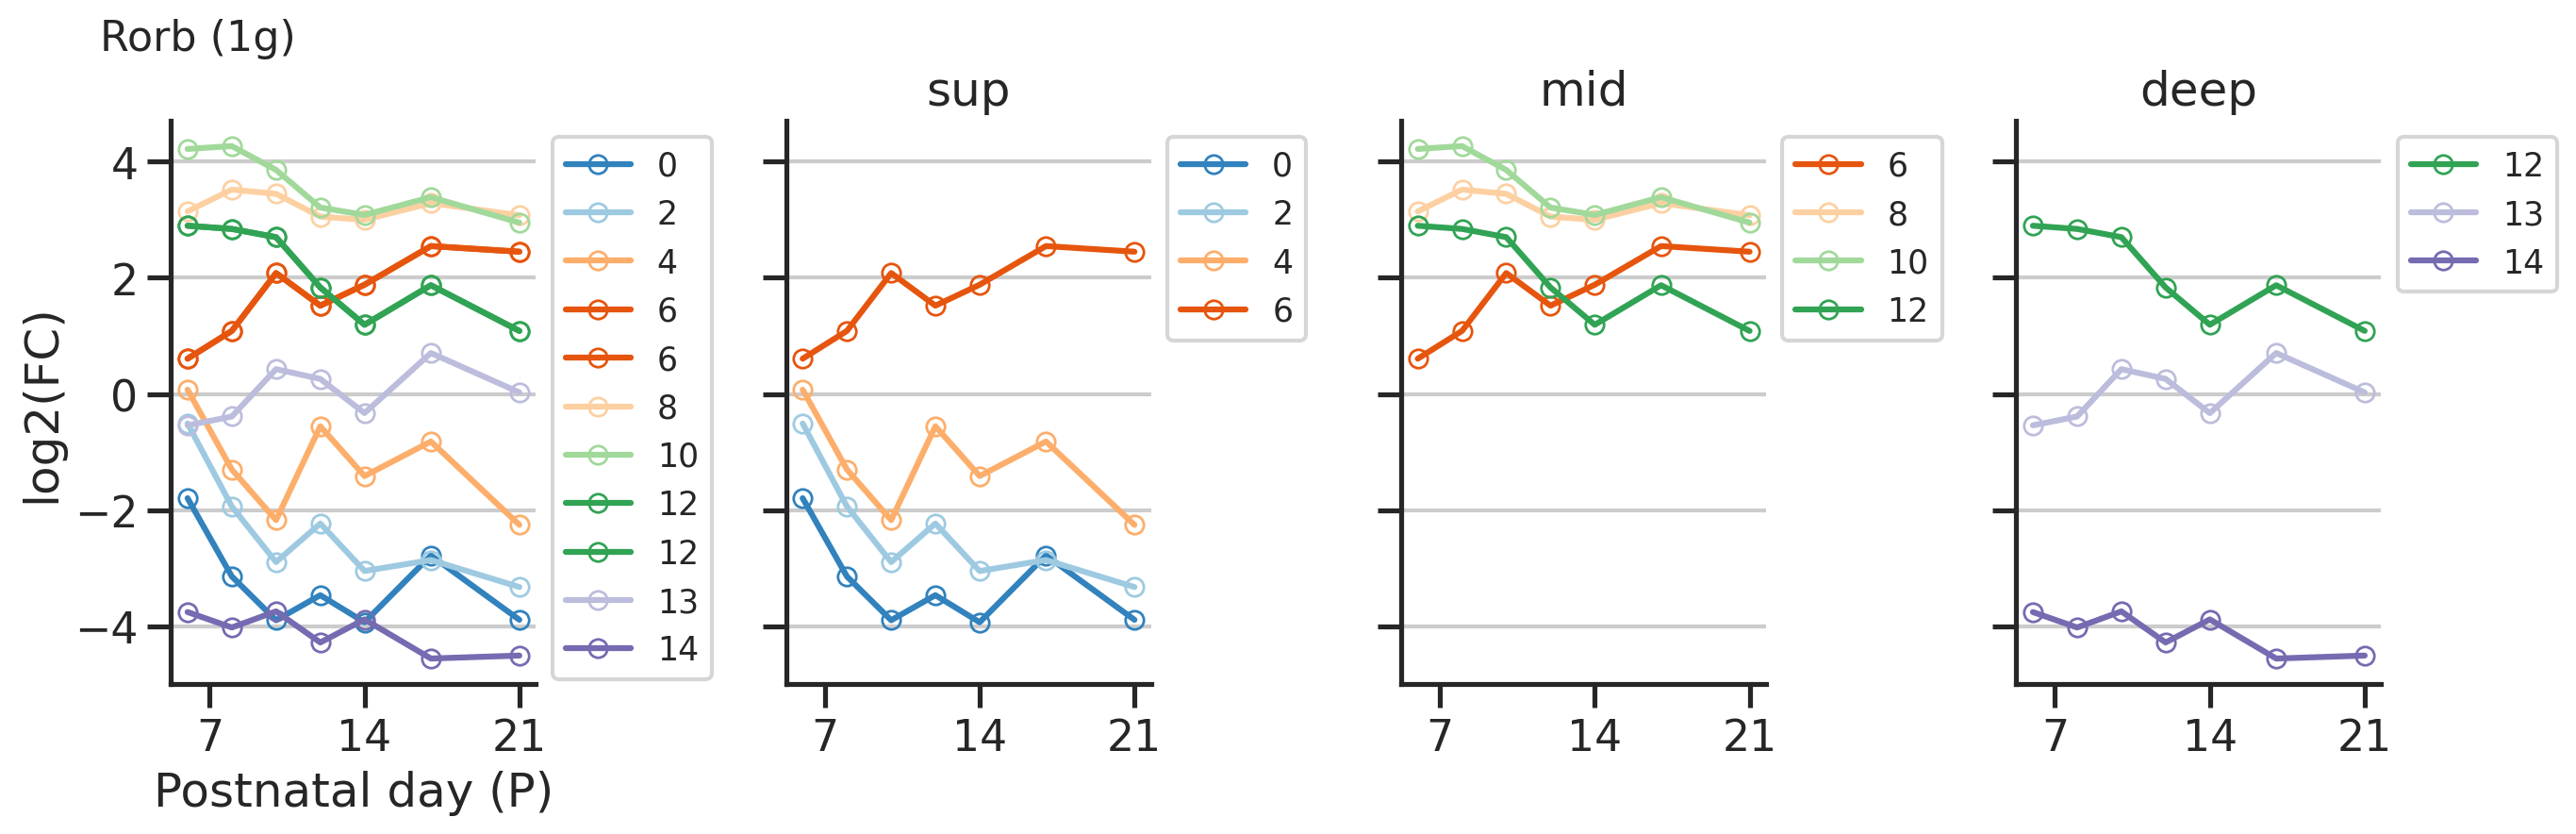

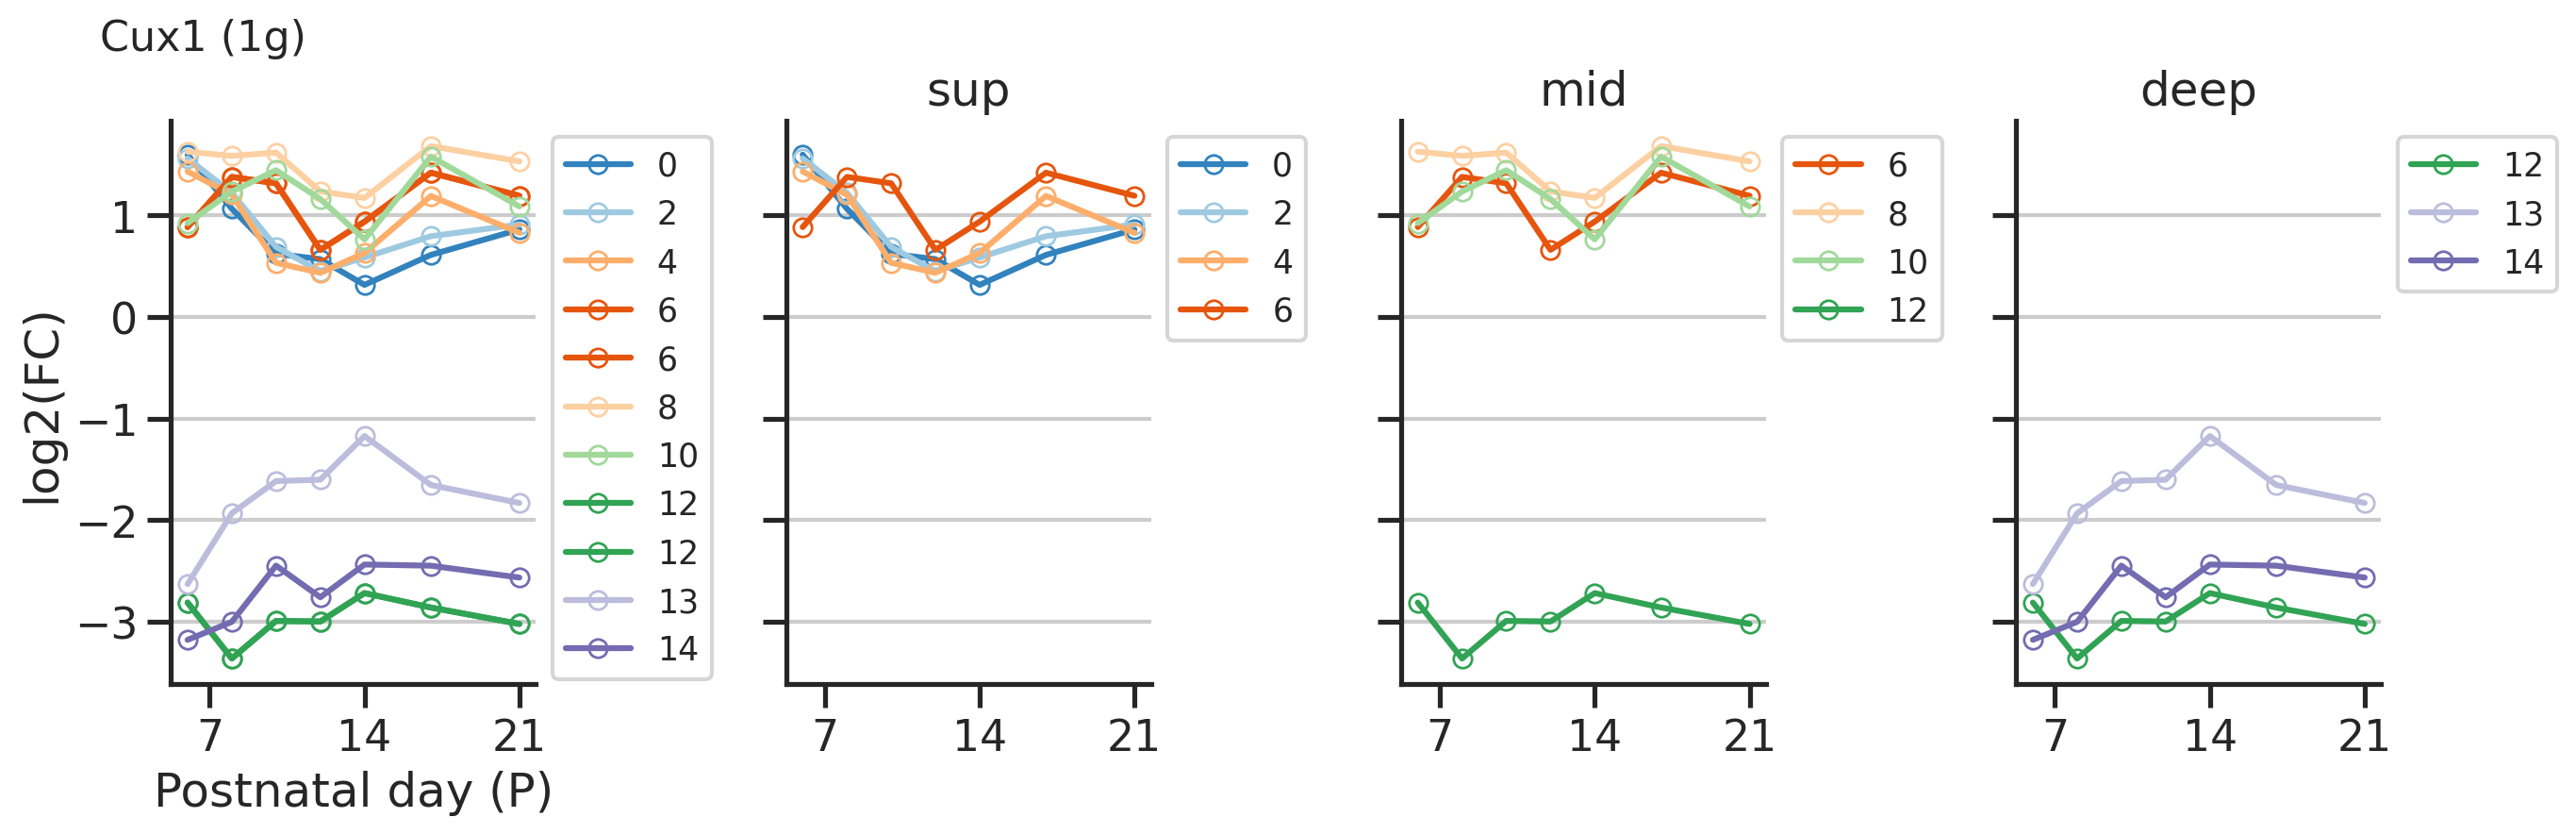

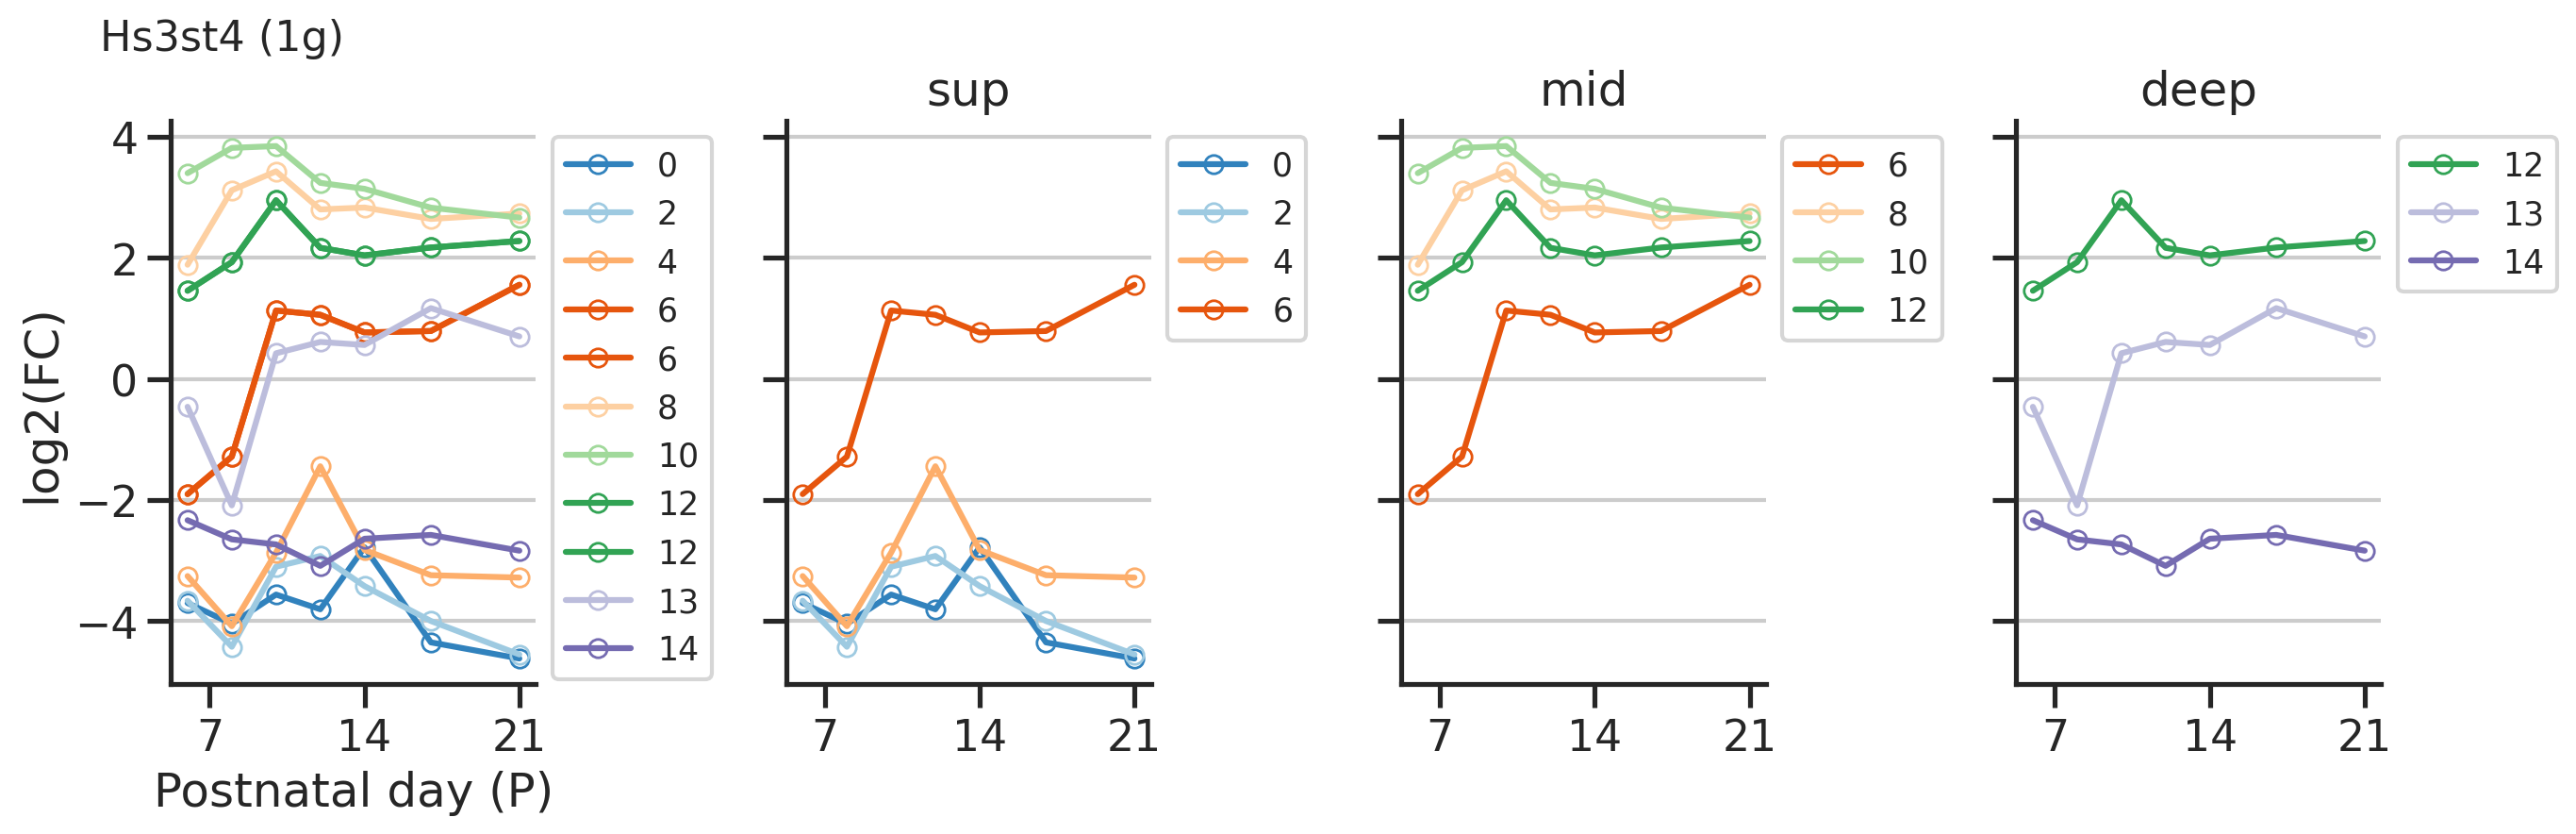

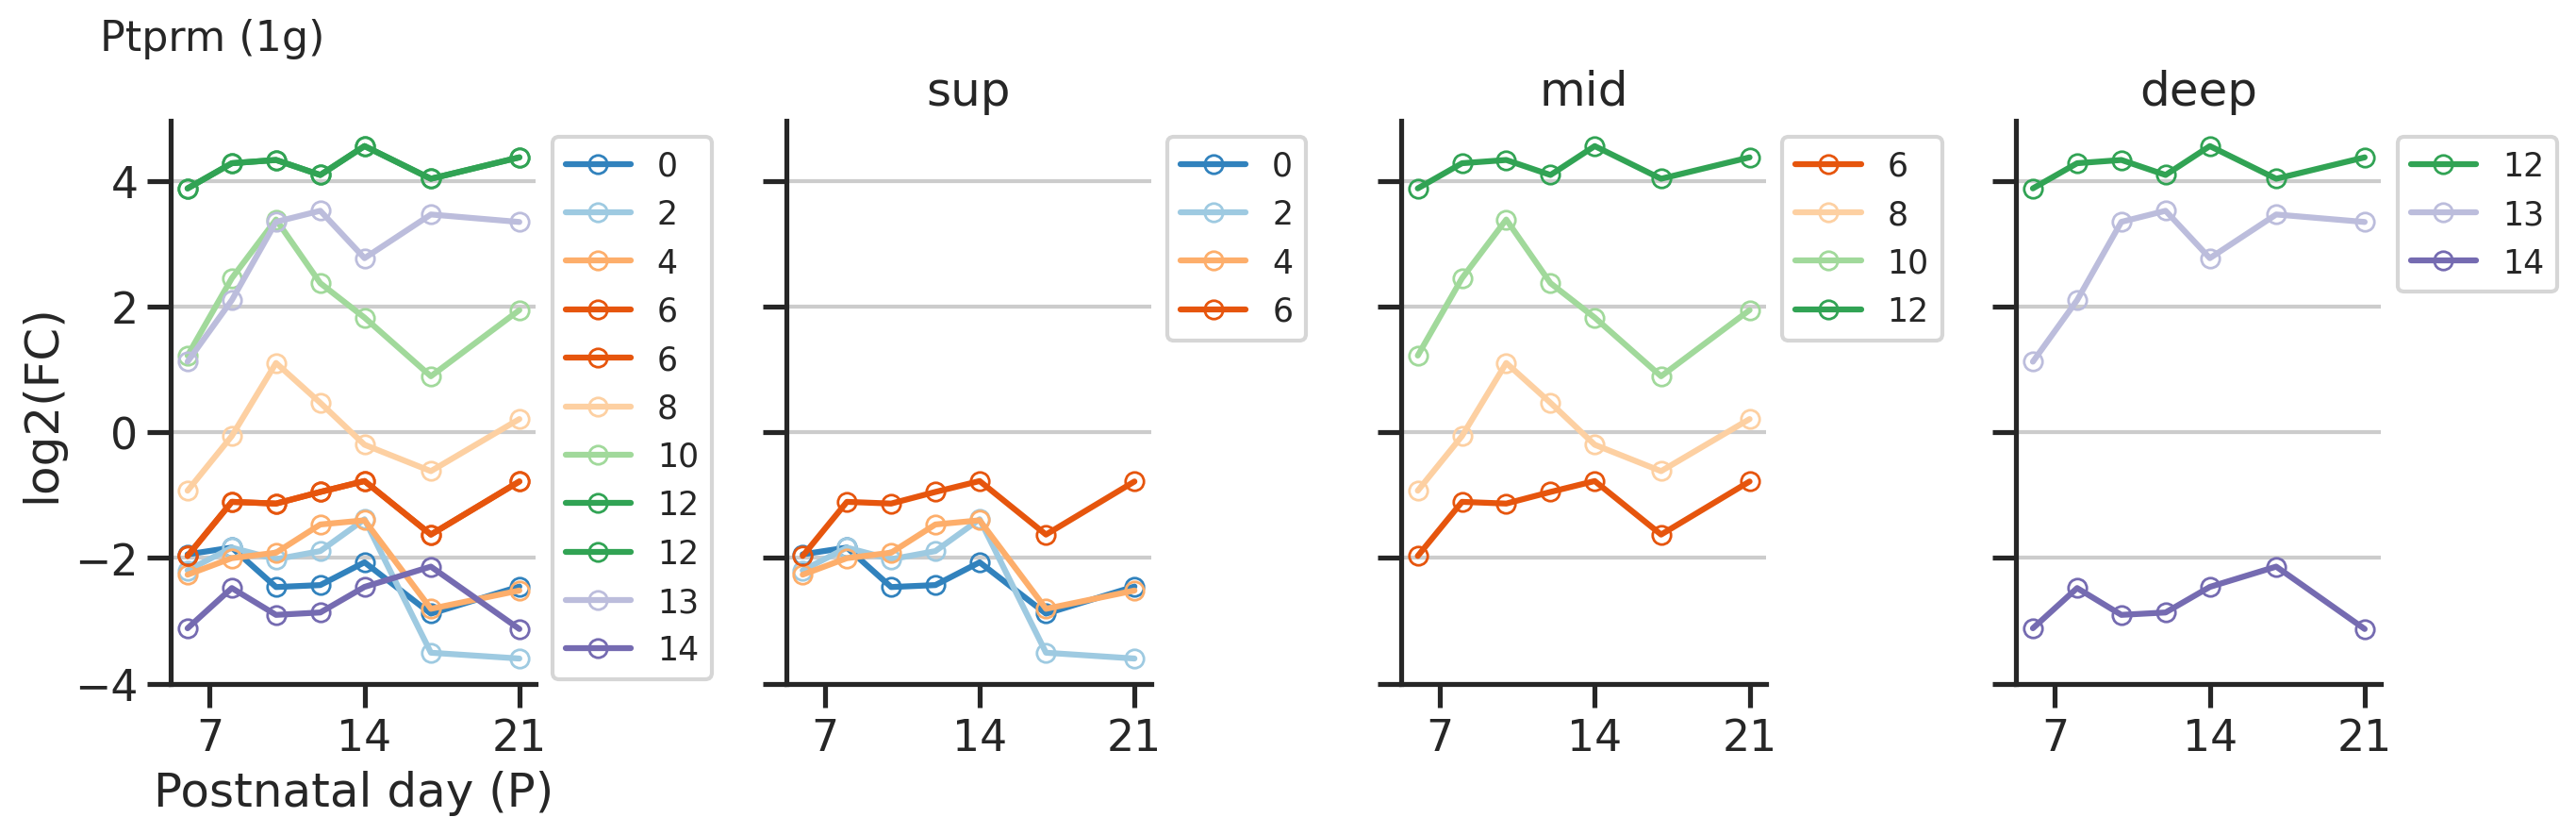

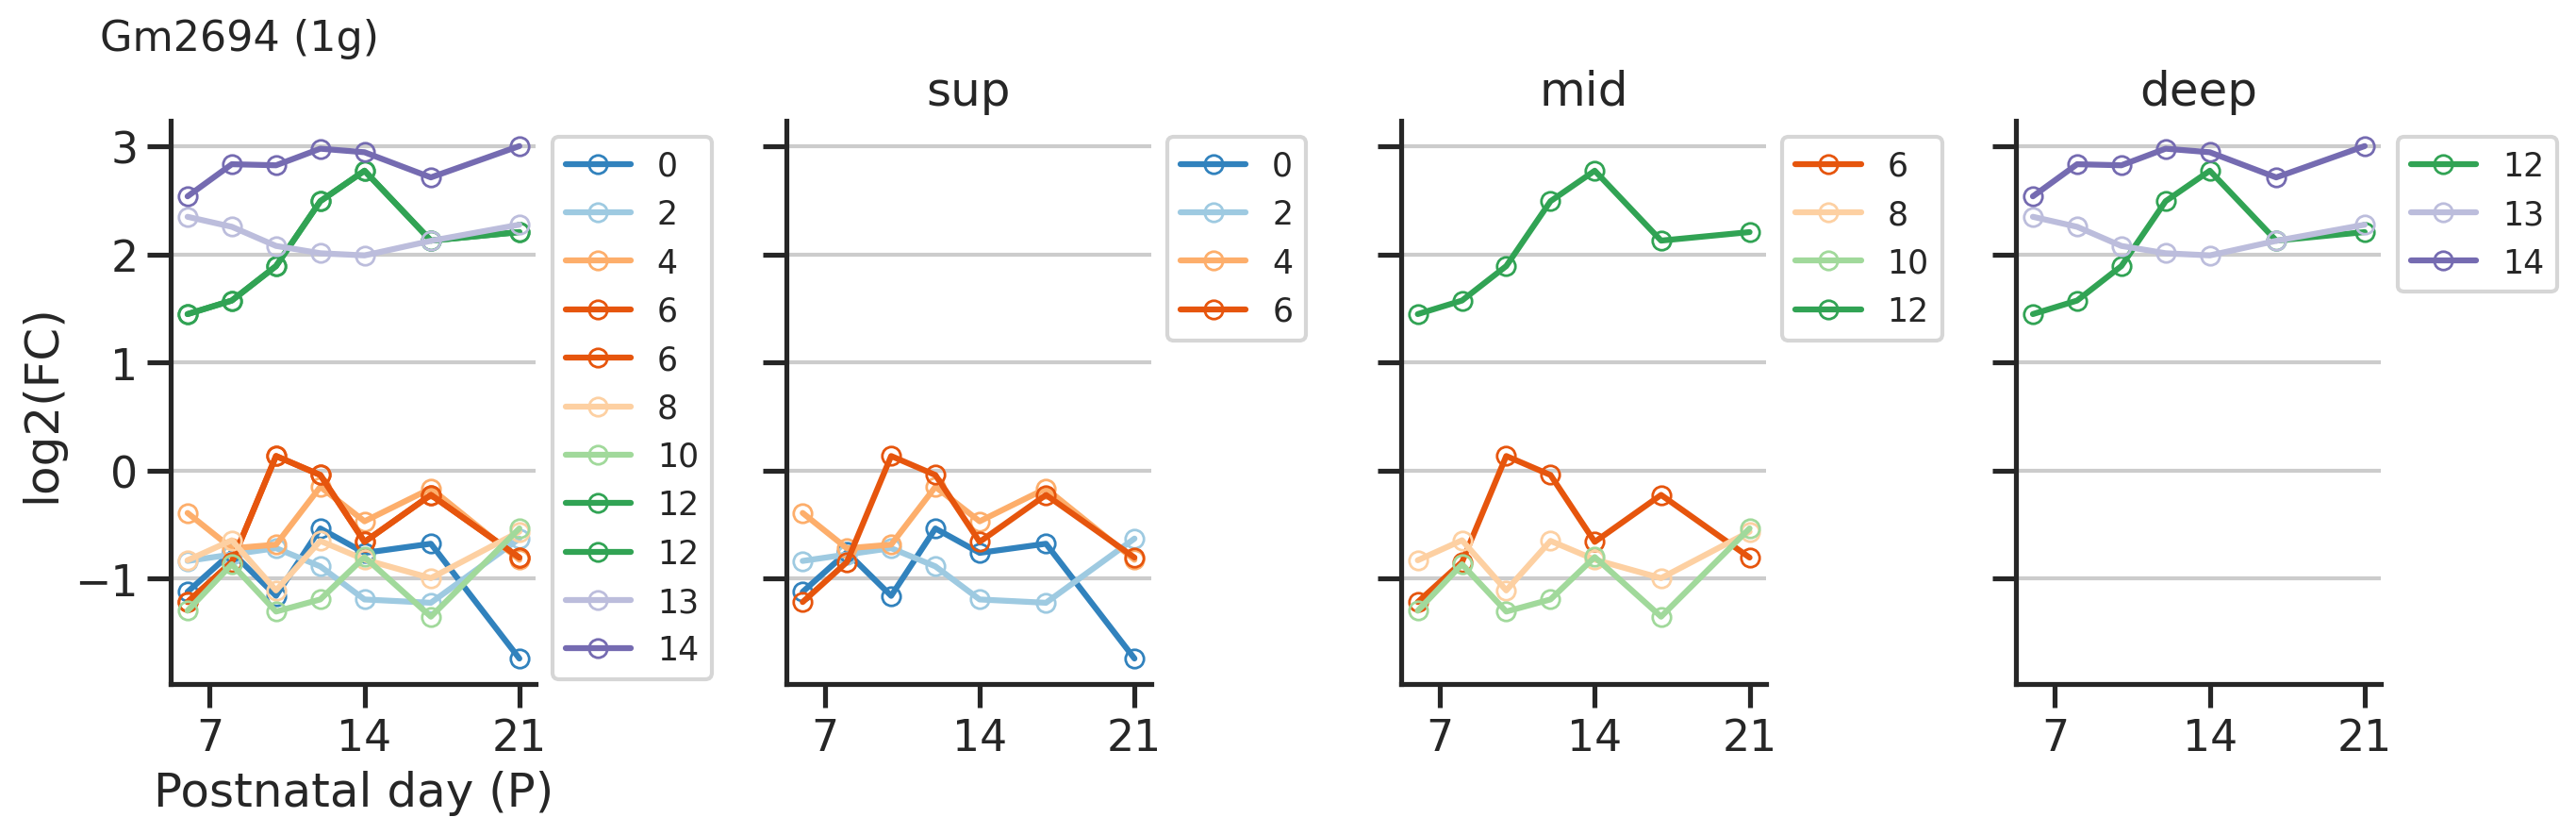

In [35]:
for reg_name in bt.genes[toptype_idx][5:10]:
    reg_genes = [reg_name]
    plot2(reg_name, baseline_gexp, reg_genes=reg_genes)

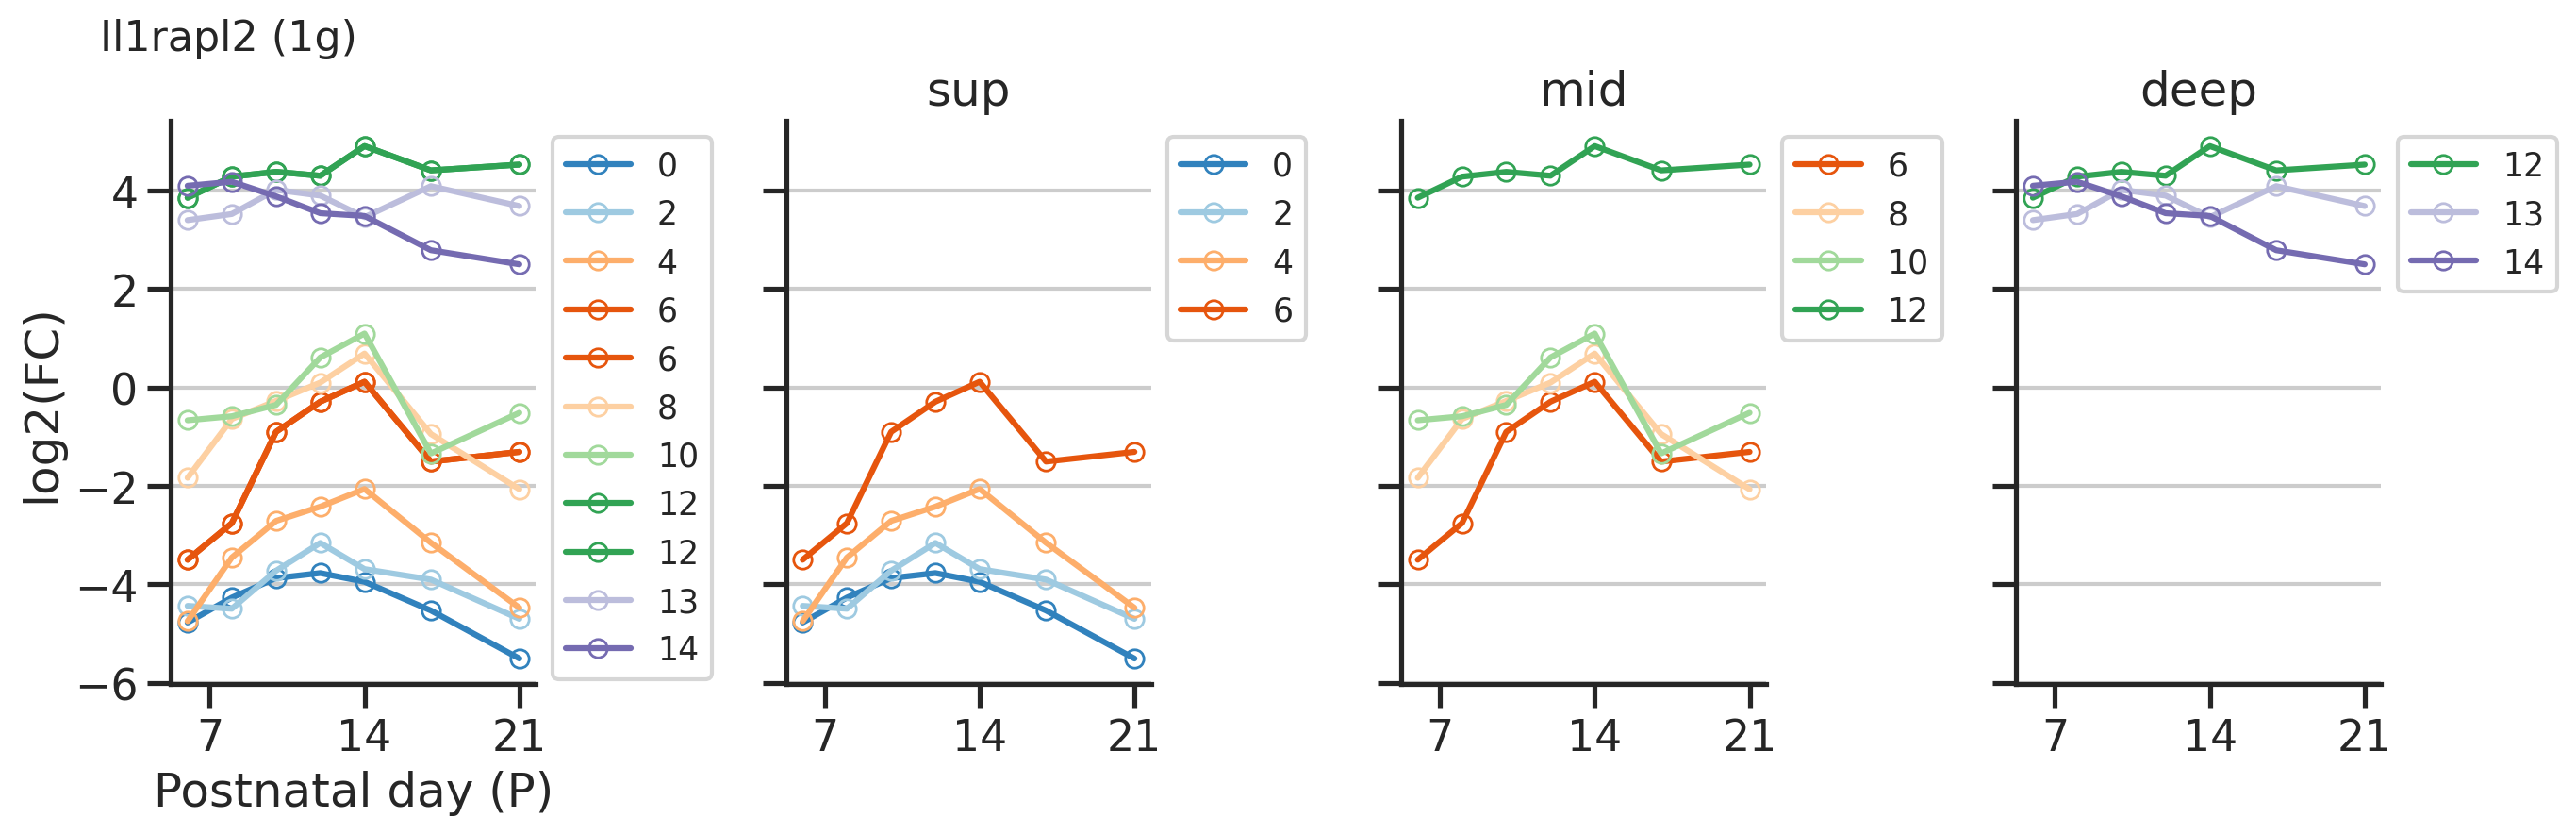

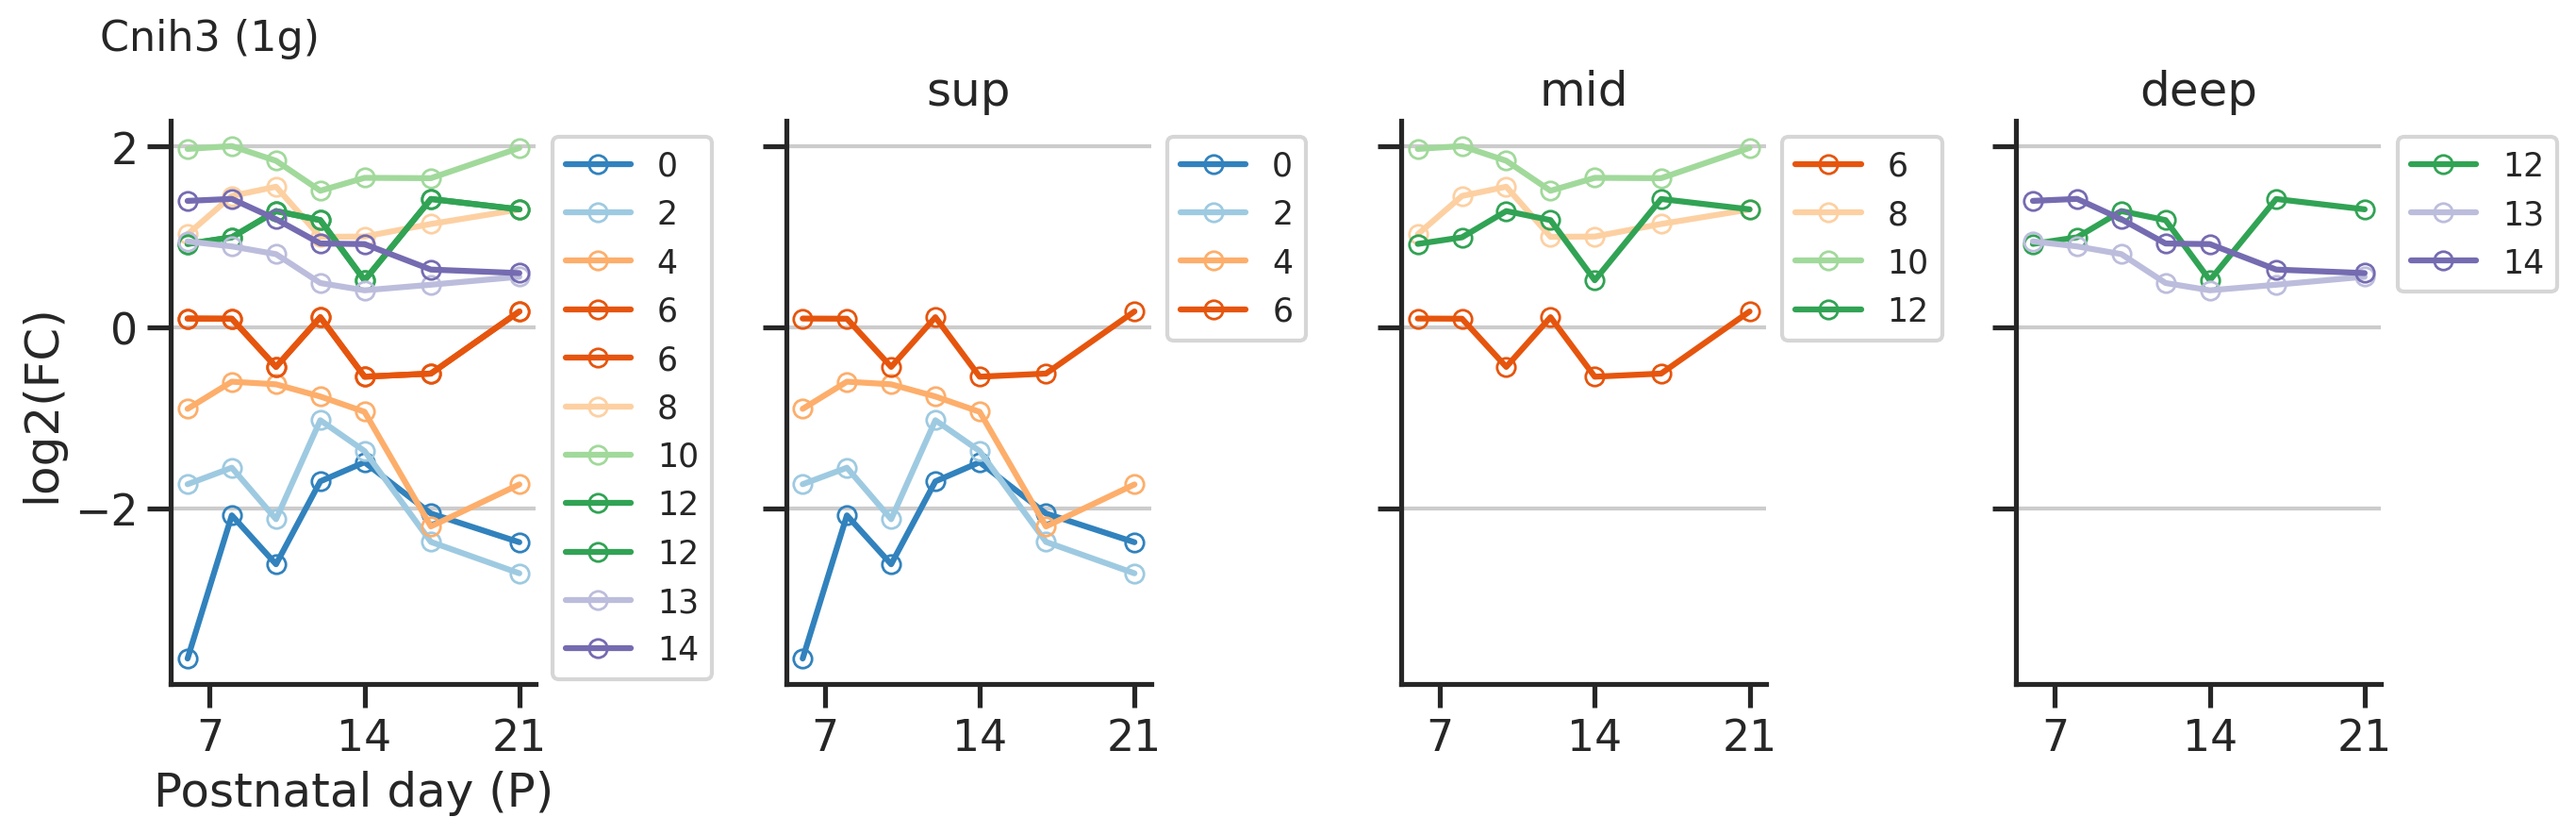

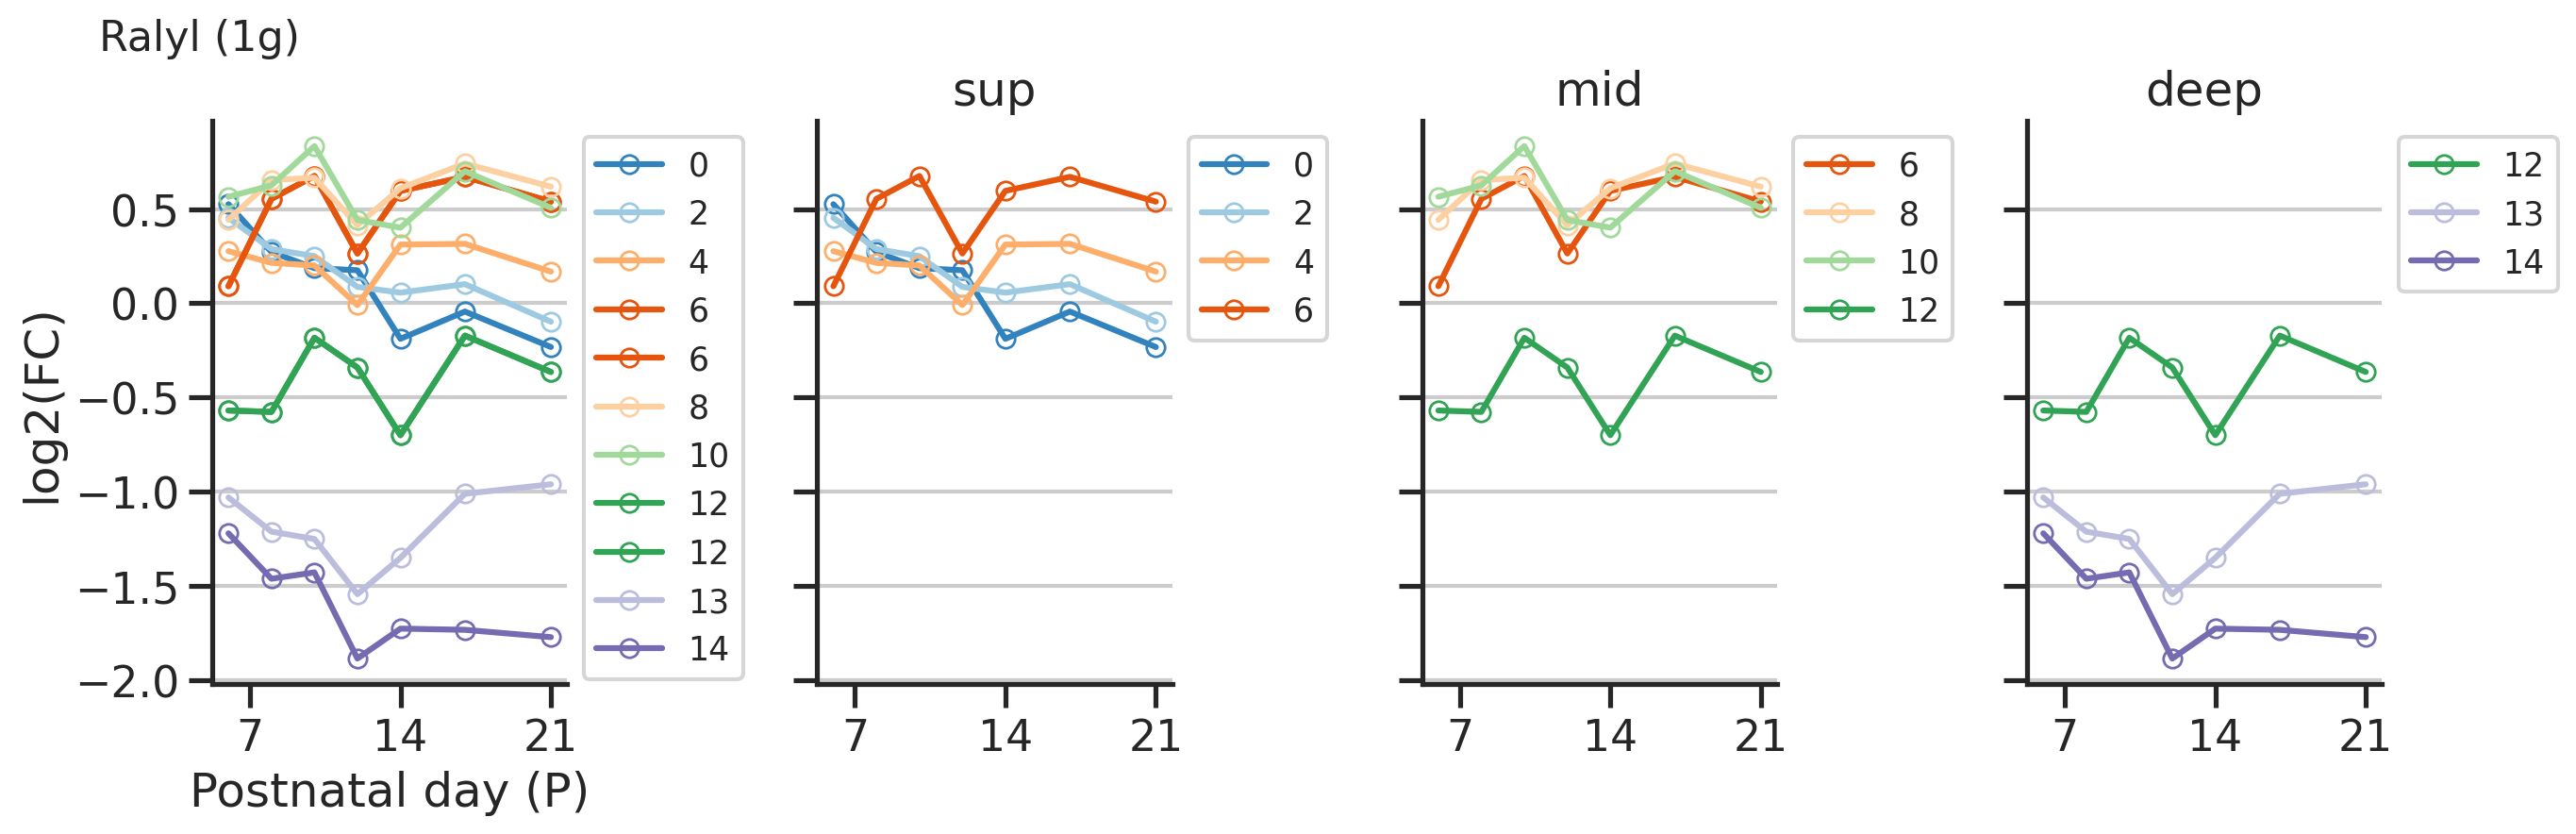

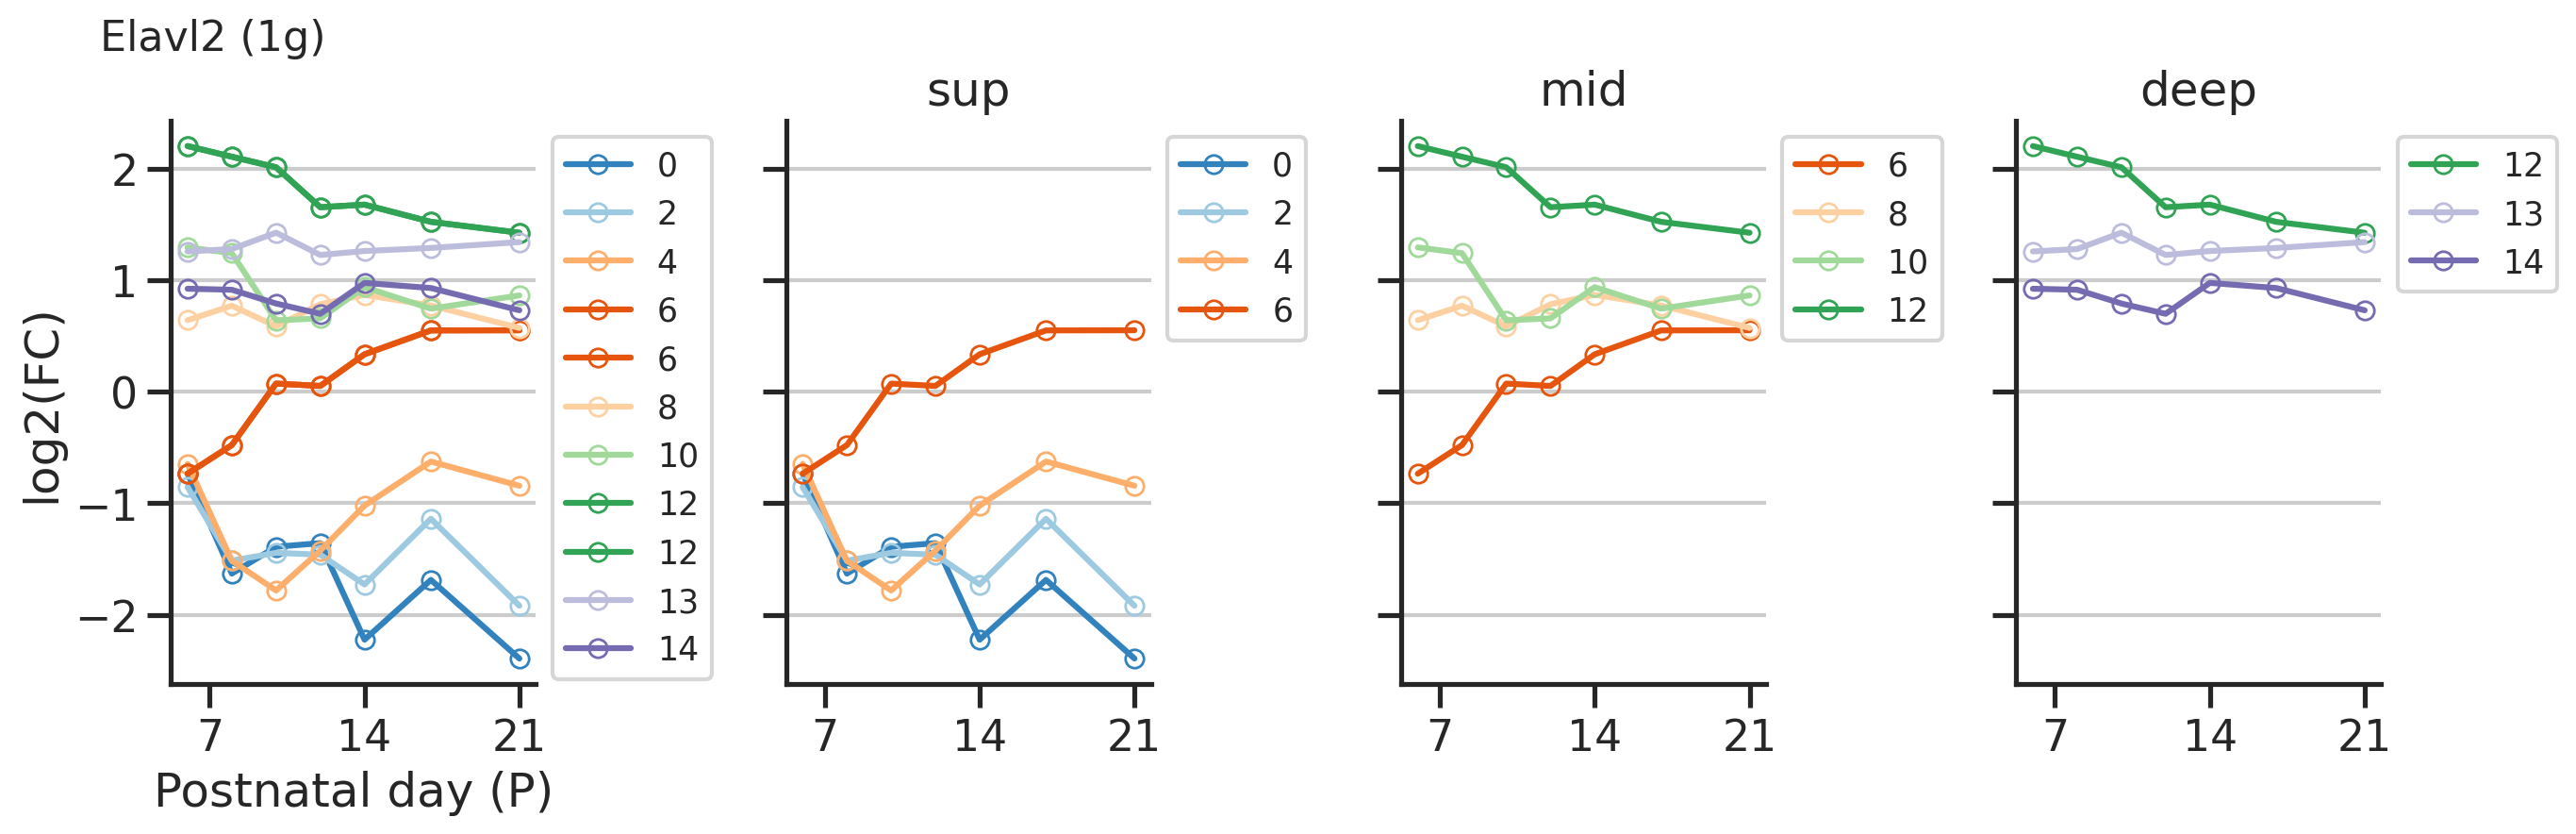

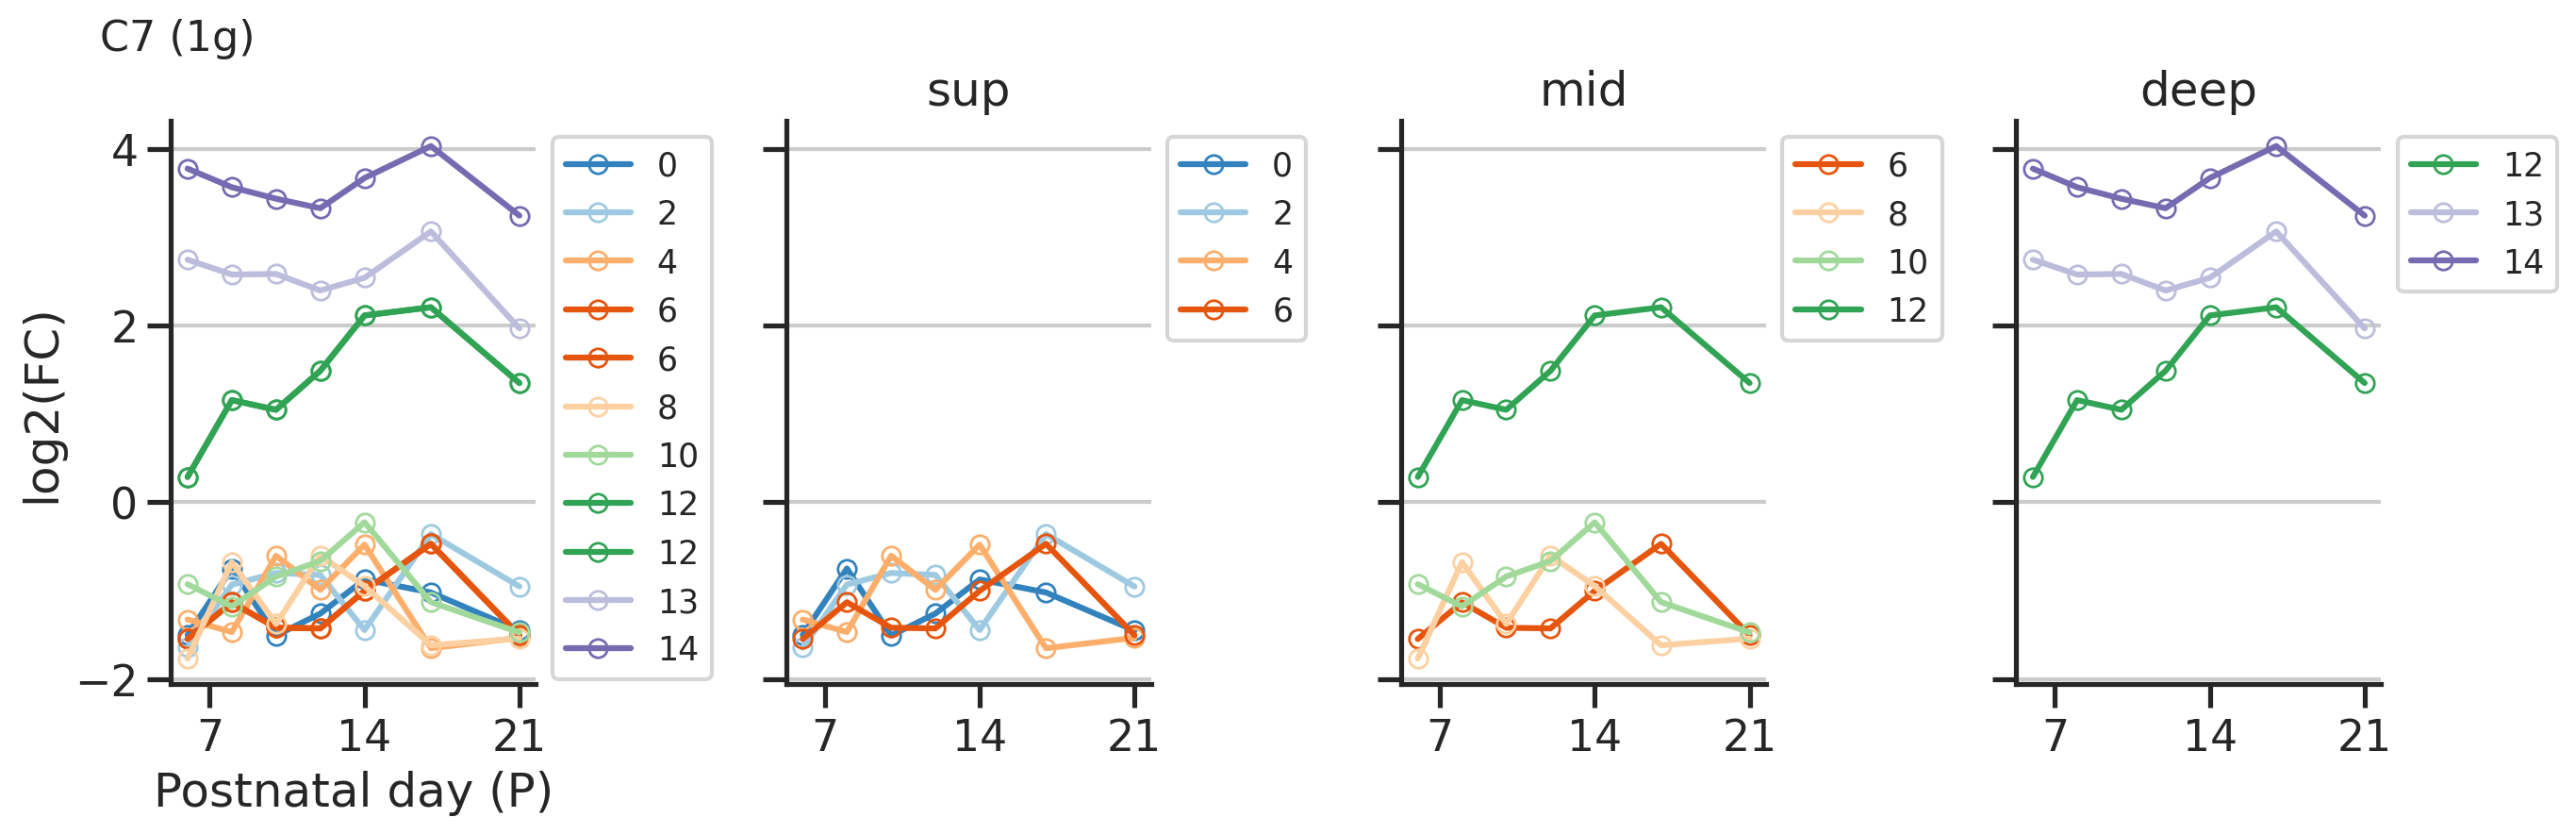

In [36]:
for reg_name in bt.genes[toptype_idx][10:15]:
    reg_genes = [reg_name]
    plot2(reg_name, baseline_gexp, reg_genes=reg_genes)